# Прогноз отмены бронирования для сети отелей UrbanStay

- Дайте название проекту, запишите его в блоке Markdown выше.
- Опишите, как вы поняли постановку задачи.
- Опишите данные для решения задачи.

**Заказчик** - сеть отелей среднего сегмента UrbanStay. Последние два года около трети броней отменяются незадолго до заезда, из-за чего загрузка держится на уровне 60-70% вместо плановых 80%. Сейчас отмены компенсируются овербукингом «на глаз», и заказчик хочет заменить интуицию управляемым инструментом.

**Что нужно сделать:**

1. Построить модель, которая по параметрам брони предсказывает вероятность её отмены.
2. Оценить экономический эффект внедрения по трём показателям: динамика доли отмен, динамика загрузки отелей и прирост дохода (Incremental Revenue, IR).

**Целевые показатели заказчика:**

- доля отмен после внедрения модели - 10%;
- загрузка отеля не должна снизиться более чем на 8%;
- относительный IR - не менее 50%.

**Данные.** Два источника в PostgreSQL:

- `hotel_bookings` - 35 341 запись о бронированиях: канал продаж, состав гостей, история клиента, стоимость, срок до заезда, длительность проживания, тип питания и номера, число пожеланий и целевой статус брони (`отказ_брони` / `нет_отказа`);
- `hotel_reviews` - 25 177 отзывов: идентификатор клиента и брони, дата отзыва, оценка проживания от 1 до 5 и текст комментария.

Целевая переменная - факт отмены брони, положительный класс (`1`) - `отказ_брони`.

## Перевод бизнес-задачи на язык машинного обучения

- Напишите, что конкретно будете делать с точки зрения Data Science: расскажите, какие модели и методы вы планируете применить для решения задачи.

**Тип задачи** - бинарная классификация с вероятностным выходом: модель должна возвращать не метку, а вероятность отмены, потому что решение о перепродаже номера принимается по порогу, а порог задаётся экономикой, а не значением 0.5.

**Метрика оптимизации** - Incremental Revenue, а не accuracy или F1. Ошибки стоят по-разному: пропущенная отмена (FN) стоит отелю 64 500 руб. упущенного дохода, а ложное срабатывание (FP) - 7 000 руб. компенсаций. Поэтому модель настраивается прямо на рубли:

$$IR_{после} = TP \cdot PerRebooking + TN \cdot AvgRev - FP \cdot CostFP - FN \cdot LostRev$$

$$IR = IR_{после} - IR_{до}, \qquad IR_{отн} = \frac{IR_{после} - IR_{до}}{IR_{до}} \cdot 100\%$$

Вспомогательные метрики ROC-AUC и PR-AUC используются как индикатор ранжирующей способности: IR зависит от порога, а AUC - нет, поэтому по ним удобно сравнивать модели между собой.

**План работы:**

1. Выгрузка обеих таблиц из PostgreSQL через SQLAlchemy.
2. EDA: качество данных, пропуски, дубликаты, аномалии, распределения и связь признаков с целевой переменной.
3. Объединение брони с отзывами по правилу «ближайший предшествующий отзыв».
4. Генерация признаков: производные от параметров брони, категоризация срока до заезда и сезона, векторизация текстов отзывов через TF-IDF.
5. Разделение на train / calibration / test в пропорции 60 / 20 / 20 со стратификацией по целевой переменной.
6. Турнир моделей Random Forest, LightGBM и CatBoost: подбор гиперпараметров в Optuna по кросс-валидации из трёх фолдов с валидационной выборкой в 2 000 объектов, критерий - IR.
7. Калибровка лучшей модели на полной обучающей выборке и поиск порога по калибровочной выборке.
8. Проверка стабильности на тестовой выборке, анализ важности признаков через SHAP.
9. Расчёт экономического эффекта и выводы для бизнеса.

**Защита от утечек.** Препроцессор (медианы для пропусков, словарь категорий, словарь TF-IDF) обучается только на train; калибровочная и тестовая выборки только преобразуются. Порог подбирается на калибровочной выборке, а тестовая используется один раз - для финальной оценки.

## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

Ячейка ниже доустанавливает пакеты, которых нет в базовом окружении платформы, и импортирует всё, что понадобится дальше. Установка идёт до импортов: на чистом ядре импорт в начале ячейки упал бы с `ModuleNotFoundError` раньше, чем отработал бы `pip`.

Функции подготовки данных, генерации признаков и расчёта бизнес-метрик вынесены в модуль `feature_pipeline.py`, который лежит рядом с тетрадью. Так один и тот же код используется и в тетради, и при инференсе сохранённой модели.

In [1]:
import importlib
import importlib.util
import json
import shutil
import site
import subprocess
import sys
import time
import warnings
from importlib.metadata import version
from pathlib import Path

# Пакеты, которых нет в базовом окружении платформы. Версии подобраны под стек
# Python 3.9 / numpy 1.21 / pandas 1.2.4 / sklearn 0.24 и не тянут его обновление.
REQUIRED = {
    "psycopg2": "psycopg2-binary==2.9.9",
    "optuna": "optuna==4.9.0",
    "lightgbm": "lightgbm==3.3.5",
    "catboost": "catboost==1.2.5",
    "numba": "numba==0.56.4",
    "shap": "shap==0.44.1",
}
to_install = [spec for module, spec in REQUIRED.items()
              if importlib.util.find_spec(module) is None]

# pandas 1.2 совместим только с SQLAlchemy 1.x: в 2.0 сменилась сигнатура MetaData,
# и pd.read_sql_query падает с TypeError ещё до запроса.
if (importlib.util.find_spec("sqlalchemy") is None
        or int(version("SQLAlchemy").split(".")[0]) >= 2):
    to_install.append("SQLAlchemy==1.4.54")

if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + to_install)
    sys.path.insert(0, site.getusersitepackages())
    importlib.invalidate_caches()

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, text

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import optuna
import shap
from catboost import CatBoostClassifier

import feature_pipeline as fp

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = fp.RANDOM_STATE
# Число потоков фиксируем явно: без этого замеры времени сравнивают не алгоритмы,
# а их настройки многопоточности по умолчанию.
N_JOBS = 4

versions = pd.DataFrame(
    [(name, version(name)) for name in
     ["pandas", "numpy", "scikit-learn", "SQLAlchemy", "lightgbm",
      "catboost", "optuna", "shap", "matplotlib", "seaborn"]],
    columns=["библиотека", "версия"],
).set_index("библиотека")
versions.columns.name = f"Python {sys.version.split()[0]}"
display(versions)

Python 3.9.25,версия
библиотека,
pandas,1.2.4
numpy,1.21.1
scikit-learn,0.24.1
SQLAlchemy,1.4.54
lightgbm,3.3.5
catboost,1.2.5
optuna,4.9.0
shap,0.44.1
matplotlib,3.3.4


## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [2]:
DB_CONFIG = {
    "host": "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net",
    "port": 6432,
    "database": "data-scientist-hotels",
    "user": "praktikum_student",
    "password": "Sdf4$2;d-d30pp",
}
connection_string = (
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}".format(**DB_CONFIG)
)
engine = create_engine(connection_string)

QUERY_BOOKINGS = "SELECT * FROM hotel_bookings"
QUERY_REVIEWS = "SELECT * FROM hotel_reviews"

# Запросы выполняем внутри одного соединения, соединение закрывается контекстным менеджером.
with engine.connect() as connection:
    bookings_raw = pd.read_sql_query(text(QUERY_BOOKINGS), connection)
    reviews_raw = pd.read_sql_query(text(QUERY_REVIEWS), connection)

loaded = pd.DataFrame(
    [
        ["hotel_bookings", bookings_raw.shape[0], bookings_raw.shape[1]],
        ["hotel_reviews", reviews_raw.shape[0], reviews_raw.shape[1]],
    ],
    columns=["таблица", "строк", "столбцов"],
).set_index("таблица")
display(loaded)
display(bookings_raw.head())
display(reviews_raw.head())

,строк,столбцов
таблица,,
hotel_bookings,35341,17
hotel_reviews,25177,5


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,"6,700.0000",21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,"62,300.0000",15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,"46,900.0000",96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,"53,600.0000",150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,"46,900.0000",96,5,2,тип_питания_1,False,тип_1,1


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


**Выводы по загрузке данных**

- Подключение к PostgreSQL собрано через `create_engine`, обе таблицы выгружены запросами `SELECT * FROM ...` внутри одного соединения.
- `hotel_bookings` - **35 341 строка и 17 столбцов**, `hotel_reviews` - **25 177 строк и 5 столбцов**. Объёмы совпадают с описанием данных в задании, то есть выгрузка полная.
- Типы пришли из базы как есть: даты (`booking_date`, `review_date`) - строки, `returning_customer` и `parking_included` - булевы, `booking_value` - число с плавающей точкой. Даты потребуют приведения к `datetime`, булевы поля - к 0/1.
- Ключ `booking_id` в обеих таблицах имеет один формат (`INN00000`), значит таблицы соединимы напрямую.

**Итог:** данные загружены полностью и в ожидаемом объёме, дальше - оценка их качества.

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [3]:
bookings_raw.info()
reviews_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

#### Пропуски, дубликаты и уникальность ключей

Проверяем каждую таблицу по трём пунктам сразу: доля пропусков по столбцам, полные дубликаты строк и уникальность ключа. В `hotel_bookings` ключ - `booking_id`, в `hotel_reviews` пара `booking_id` + `review_date` (один гость мог оставить несколько отзывов по одной поездке).

In [4]:
def quality_report(df, name):
    """Сводка по пропускам и типам одной таблицы."""
    report = pd.DataFrame({
        "тип": df.dtypes.astype(str),
        "пропусков": df.isna().sum(),
        "доля_пропусков_%": (df.isna().mean() * 100).round(2),
        "уникальных": df.nunique(),
    })
    report.columns.name = name
    return report


display(quality_report(bookings_raw, "hotel_bookings"))
display(quality_report(reviews_raw, "hotel_reviews"))

keys = pd.DataFrame(
    [
        ["hotel_bookings", len(bookings_raw), int(bookings_raw.duplicated().sum()),
         int(bookings_raw["booking_id"].duplicated().sum()), bookings_raw["booking_id"].nunique()],
        ["hotel_reviews", len(reviews_raw), int(reviews_raw.duplicated().sum()),
         int(reviews_raw.duplicated(subset=["booking_id", "review_date"]).sum()),
         reviews_raw["booking_id"].nunique()],
    ],
    columns=["таблица", "строк", "полных_дублей", "дублей_по_ключу", "уникальных_booking_id"],
).set_index("таблица")
display(keys)

# Дубли booking_id могут быть как техническими копиями, так и конфликтом данных:
# проверяем, различаются ли строки внутри группы хотя бы одним столбцом.
duplicated_ids = bookings_raw.loc[bookings_raw["booking_id"].duplicated(), "booking_id"].unique()
conflicts = (
    bookings_raw[bookings_raw["booking_id"].isin(duplicated_ids)]
    .groupby("booking_id")
    .nunique()
    .max()
    .rename("максимум_различных_значений_внутри_booking_id")
    .to_frame()
)
display(conflicts.T)

hotel_bookings,тип,пропусков,доля_пропусков_%,уникальных
booking_id,object,0,0.0000,30733
booking_date,object,0,0.0000,2445
sales_channel,object,0,0.0000,3
adult_count,int64,0,0.0000,6
child_count,int64,0,0.0000,3
returning_customer,bool,0,0.0000,2
previous_cancellations,int64,0,0.0000,6
previous_no_shows,int64,0,0.0000,6
booking_status,object,0,0.0000,2
booking_value,float64,0,0.0000,1766


hotel_reviews,тип,пропусков,доля_пропусков_%,уникальных
customer_id,object,0,0.0000,13429
booking_id,object,0,0.0000,21883
review_date,object,0,0.0000,2514
stay_rating,int64,0,0.0000,4
review_text,object,0,0.0000,14153


,строк,полных_дублей,дублей_по_ключу,уникальных_booking_id
таблица,,,,
hotel_bookings,35341,4608,4608,30733
hotel_reviews,25177,0,130,21883


,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
максимум_различных_значений_внутри_booking_id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


#### Целевая переменная

Смотрим баланс классов: от него зависит и выбор метрики, и стратификация при разбиении выборок.

booking_status,бронирований,доля_%
нет_отказа,25177,71.2400
отказ_брони,10164,28.7600


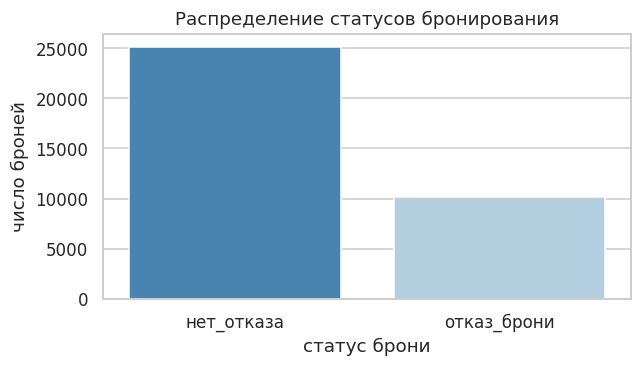

In [5]:
target_share = (
    bookings_raw["booking_status"]
    .value_counts(dropna=False)
    .to_frame("бронирований")
    .assign(доля_=lambda d: (d["бронирований"] / len(bookings_raw) * 100).round(2))
    .rename(columns={"доля_": "доля_%"})
)
target_share.columns.name = "booking_status"
display(target_share)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=target_share.index, y=target_share["бронирований"], ax=ax, palette="Blues_r")
ax.set_title("Распределение статусов бронирования")
ax.set_xlabel("статус брони")
ax.set_ylabel("число броней")
fig.tight_layout()
plt.show()

#### Количественные признаки

Описательные статистики и гистограммы по всем числовым столбцам таблицы бронирований.

,count,mean,std,min,25%,50%,75%,max
adult_count,"35,341.0000",12.4800,45.7300,1.0000,1.0000,2.0000,3.0000,300.0000
child_count,"35,341.0000",0.3600,0.5900,0.0000,0.0000,0.0000,1.0000,2.0000
previous_cancellations,"35,341.0000",0.3600,0.6300,0.0000,0.0000,0.0000,1.0000,5.0000
previous_no_shows,"35,341.0000",0.8400,0.9300,0.0000,0.0000,1.0000,1.0000,5.0000
booking_value,"35,341.0000","61,634.0600","42,837.5900",0.0000,"33,500.0000","53,600.0000","80,400.0000","417,221.2000"
days_until_checkin,"35,341.0000",100.5200,71.8700,2.0000,45.0000,90.0000,144.0000,300.0000
weekday_nights,"35,341.0000",6.5300,3.3400,1.0000,5.0000,6.0000,9.0000,15.0000
weekend_nights,"35,341.0000",1.9500,1.4800,0.0000,0.0000,2.0000,2.0000,6.0000
customer_special_requests,"35,341.0000",0.6200,0.7800,0.0000,0.0000,0.0000,1.0000,5.0000


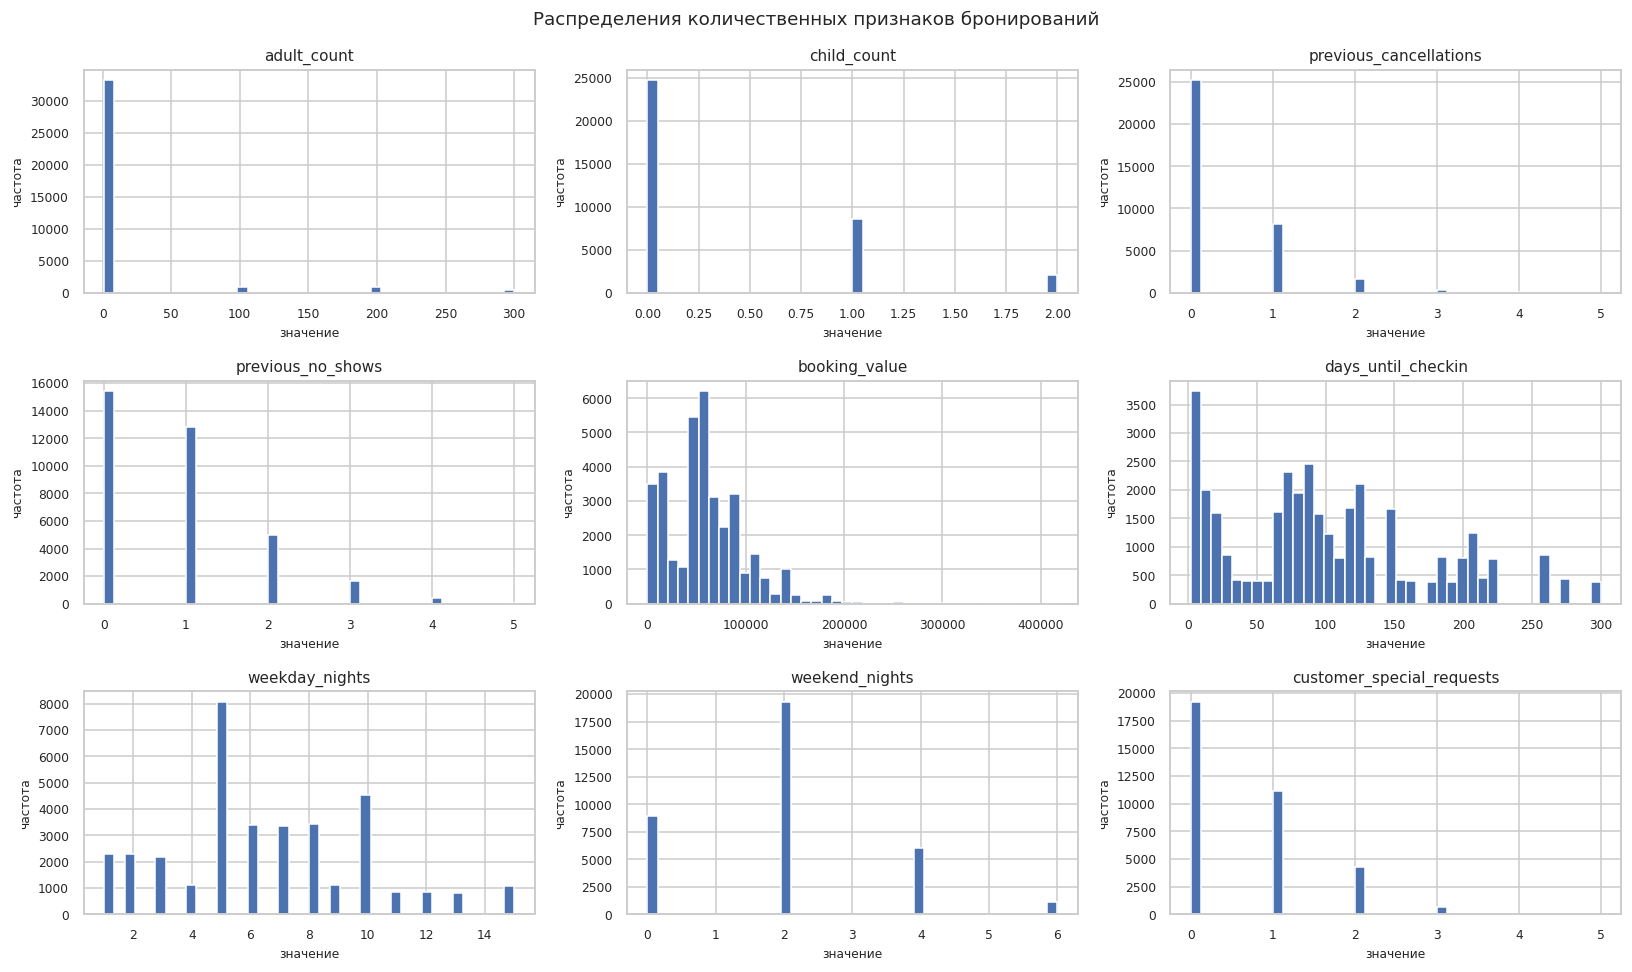

In [6]:
NUM_RAW = [
    "adult_count", "child_count", "previous_cancellations", "previous_no_shows",
    "booking_value", "days_until_checkin", "weekday_nights", "weekend_nights",
    "customer_special_requests",
]
display(bookings_raw[NUM_RAW].describe().T.round(2))

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, column in zip(axes.ravel(), NUM_RAW):
    ax.hist(bookings_raw[column], bins=40, color="#4C72B0")
    ax.set_title(column, fontsize=10)
    ax.set_xlabel("значение", fontsize=8)
    ax.set_ylabel("частота", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Распределения количественных признаков бронирований", fontsize=12)
fig.tight_layout()
plt.show()

#### Выбросы

Боксплоты показывают точки за усами, но не дают счётчика, поэтому рядом считаем сводку по правилу 1.5 IQR: границы уса, число и долю наблюдений за ним.

,p25,p75,нижний_ус,верхний_ус,за_усами,за_усами_%,максимум
признак,,,,,,,
adult_count,1.0000,3.0000,-2.0000,6.0000,2151,6.0900,300.0000
child_count,0.0000,1.0000,-1.5000,2.5000,0,0.0000,2.0000
previous_cancellations,0.0000,1.0000,-1.5000,2.5000,367,1.0400,5.0000
previous_no_shows,0.0000,1.0000,-1.5000,2.5000,2137,6.0500,5.0000
booking_value,"33,500.0000","80,400.0000","-36,850.0000","150,750.0000",1006,2.8500,"417,221.2000"
days_until_checkin,45.0000,144.0000,-103.5000,292.5000,375,1.0600,300.0000
weekday_nights,5.0000,9.0000,-1.0000,15.0000,0,0.0000,15.0000
weekend_nights,0.0000,2.0000,-3.0000,5.0000,1082,3.0600,6.0000
customer_special_requests,0.0000,1.0000,-1.5000,2.5000,706,2.0000,5.0000


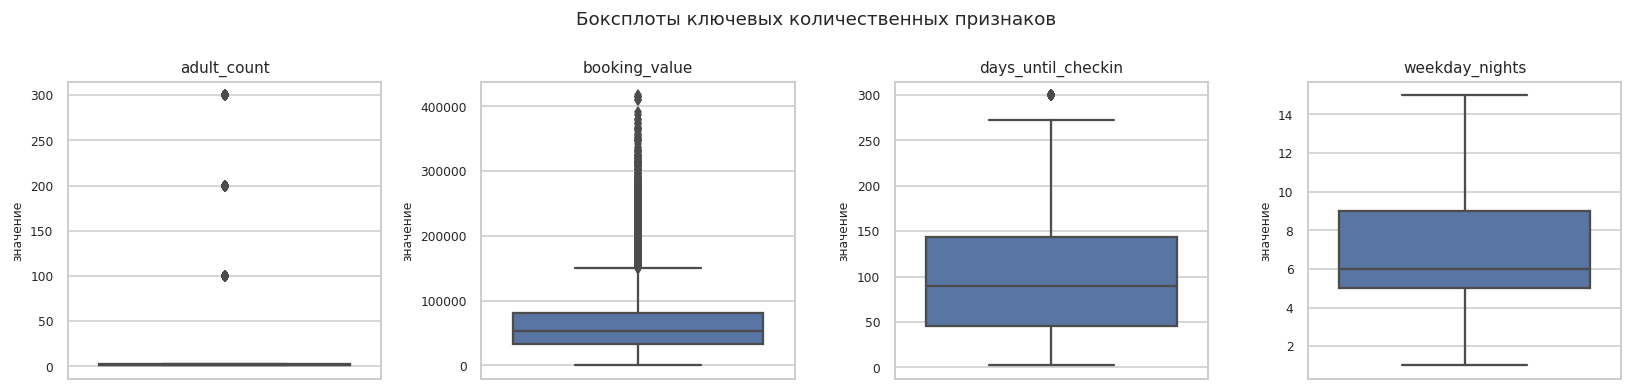

In [7]:
def iqr_summary(df, columns):
    """Сводка по правилу 1.5 IQR: границы усов и число наблюдений за ними."""
    rows = []
    for column in columns:
        series = df[column]
        q25, q75 = series.quantile([0.25, 0.75])
        iqr = q75 - q25
        low, high = q25 - 1.5 * iqr, q75 + 1.5 * iqr
        outliers = int(((series < low) | (series > high)).sum())
        rows.append([column, q25, q75, low, high, outliers,
                     round(outliers / len(series) * 100, 2), series.max()])
    return pd.DataFrame(
        rows,
        columns=["признак", "p25", "p75", "нижний_ус", "верхний_ус",
                 "за_усами", "за_усами_%", "максимум"],
    ).set_index("признак")


display(iqr_summary(bookings_raw, NUM_RAW))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, column in zip(axes, ["adult_count", "booking_value", "days_until_checkin", "weekday_nights"]):
    sns.boxplot(y=bookings_raw[column], ax=ax, color="#4C72B0")
    ax.set_title(column, fontsize=10)
    ax.set_ylabel("значение", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Боксплоты ключевых количественных признаков", fontsize=12)
fig.tight_layout()
plt.show()

#### Аномалии

Три находки требуют отдельной проверки: нереальное число взрослых в брони, нулевая стоимость и опечатка в справочнике питания.

In [8]:
anomaly_adults = (
    bookings_raw.loc[bookings_raw["adult_count"] >= 10, "adult_count"]
    .value_counts()
    .sort_index()
    .to_frame("строк")
)
anomaly_adults.columns.name = "adult_count >= 10"
display(anomaly_adults)

zero_value = bookings_raw[bookings_raw["booking_value"] == 0]
zero_stats = pd.DataFrame(
    [
        ["строк с booking_value = 0", len(zero_value)],
        ["доля от всех броней, %", round(len(zero_value) / len(bookings_raw) * 100, 2)],
        ["минимальная ненулевая стоимость", bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_value"].min()],
        ["доля отмен среди нулевых", round((zero_value["booking_status"] == "отказ_брони").mean(), 4)],
        ["доля отмен среди остальных",
         round((bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_status"] == "отказ_брони").mean(), 4)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(zero_stats)

meal_plans = bookings_raw["meal_plan"].value_counts().to_frame("строк")
meal_plans.columns.name = "meal_plan"
display(meal_plans)

adult_count >= 10,строк
100,884
200,872
300,395


,значение
показатель,
строк с booking_value = 0,"1,421.0000"
"доля от всех броней, %",4.0200
минимальная ненулевая стоимость,"6,700.0000"
доля отмен среди нулевых,0.2892
доля отмен среди остальных,0.2875


meal_plan,строк
тип_питания_1,27182
не выбран,4426
тип_питания_2,3219
не выбрант,507
тип_питания_3,7


#### Категориальные признаки

Для каждой категории смотрим наполненность и долю отмен: именно разница долей показывает, несёт ли признак сигнал о целевой переменной.

броней  доля_отмен_%
признак                значение                                        
sales_channel          корпоративное_бронирование   11747       16.7900
                       онлайн_бронирование          11554       41.4200
                       офлайн_бронирование          12040       28.2900
meal_plan              не выбран                     4426       28.9900
                       не выбрант                     507       31.3600
                       тип_питания_1                27182       28.7400
                       тип_питания_2                 3219       28.1800
                       тип_питания_3                    7       28.5700
room_type              тип_1                        27197       29.0300
                       тип_2                          658       27.5100
                       тип_3                           10       30.0000
                       тип_4                         6070       28.1400
                       тип_5                          272       25.3700
                       тип_6                          959       27.4200
                       тип_7                          175       26.2900
returning_customer     False                        15413       29.2600
                       True                         19928       28.3700
parking_included       False                        34165       28.6800
                       True                          1176       31.2100
previous_cancellations 0                            25152       25.2300
                       1                             8198       35.0800
                       2                             1624       45.3800
                       3                              304       58.8800
                       4                               59       38.9800
                       5                                4      100.0000
child_count            0                            24683       31.8400
                       1                             8629       15.8500
                       2                             2029       46.1800

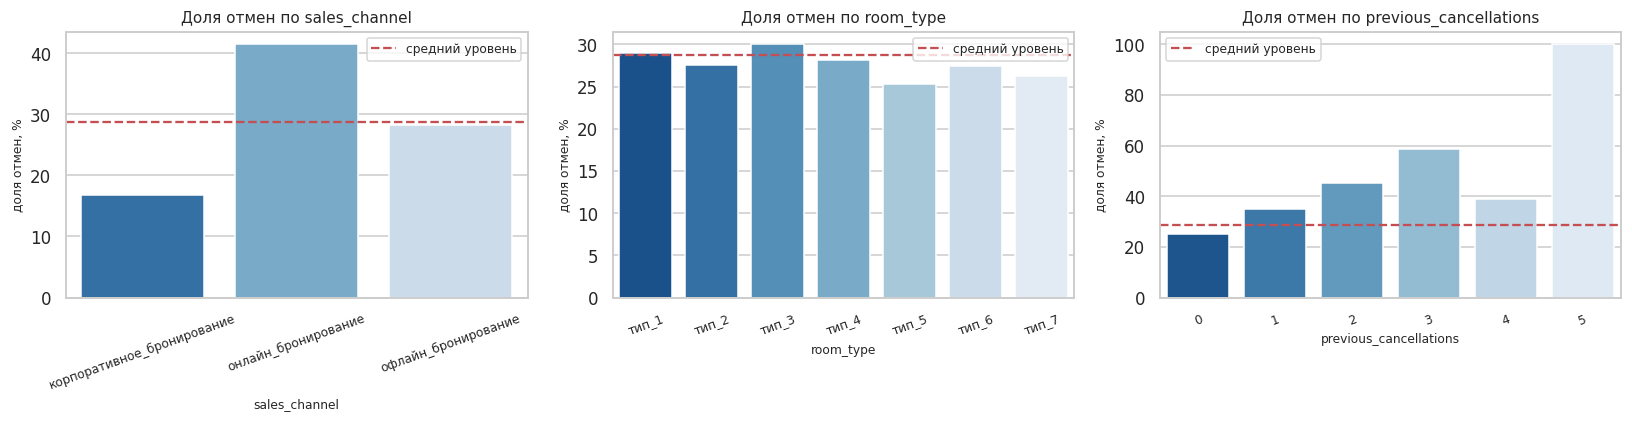

In [9]:
CAT_RAW = ["sales_channel", "meal_plan", "room_type", "returning_customer",
           "parking_included", "previous_cancellations", "child_count"]
cancel_flag = (bookings_raw["booking_status"] == "отказ_брони").astype(int)

cat_report = []
for column in CAT_RAW:
    grouped = cancel_flag.groupby(bookings_raw[column]).agg(["size", "mean"])
    grouped.columns = ["броней", "доля_отмен"]
    grouped["доля_отмен_%"] = (grouped["доля_отмен"] * 100).round(2)
    grouped = grouped.drop(columns="доля_отмен").reset_index()
    grouped.insert(0, "признак", column)
    grouped = grouped.rename(columns={column: "значение"})
    grouped["значение"] = grouped["значение"].astype(str)
    cat_report.append(grouped)
cat_report = pd.concat(cat_report, ignore_index=True).set_index(["признак", "значение"])
display(cat_report)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ["sales_channel", "room_type", "previous_cancellations"]):
    rates = cancel_flag.groupby(bookings_raw[column]).mean().mul(100)
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, palette="Blues_r")
    ax.axhline(cancel_flag.mean() * 100, color="#C44E52", linestyle="--", label="средний уровень")
    ax.set_title(f"Доля отмен по {column}", fontsize=10)
    ax.set_xlabel(column, fontsize=8)
    ax.set_ylabel("доля отмен, %", fontsize=8)
    ax.tick_params(labelsize=8, axis="x", rotation=20)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

#### Связь количественных признаков с отменой

Корреляция Пирсона с бинарной целевой переменной показывает силу монотонной связи, а средние значения в разрезе статуса - её направление.

,корреляция_с_отменой,нет_отказа,отказ_брони
days_until_checkin,0.2824,87.6300,132.4700
previous_cancellations,0.1363,0.3000,0.4900
weekday_nights,-0.0751,6.6900,6.1400
weekend_nights,-0.0670,2.0200,1.8000
booking_value,-0.0582,"63,217.5800","57,711.5500"
child_count,-0.0433,0.3800,0.3200
previous_no_shows,-0.0297,0.8600,0.8000
customer_special_requests,-0.0081,0.6300,0.6100
adult_count,0.0051,12.3300,12.8500


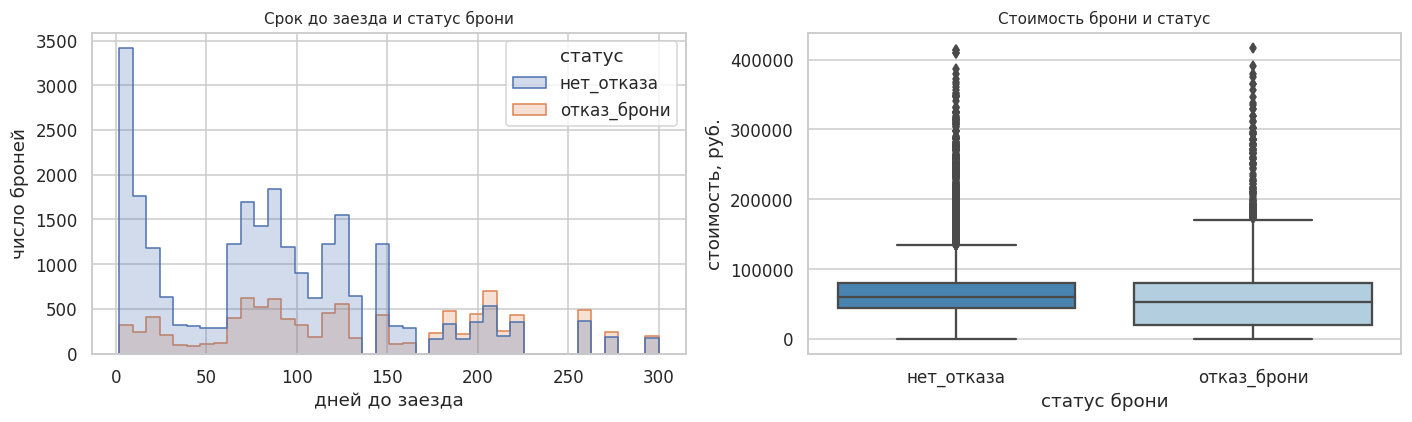

In [10]:
corr_target = (
    bookings_raw[NUM_RAW]
    .assign(is_cancelled=cancel_flag)
    .corr()["is_cancelled"]
    .drop("is_cancelled")
    .sort_values(key=abs, ascending=False)
    .round(4)
    .to_frame("корреляция_с_отменой")
)
means_by_status = bookings_raw.groupby("booking_status")[NUM_RAW].mean().T.round(2)
display(corr_target.join(means_by_status))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=bookings_raw.assign(статус=bookings_raw["booking_status"]),
             x="days_until_checkin", hue="статус", bins=40, ax=axes[0], element="step")
axes[0].set_title("Срок до заезда и статус брони", fontsize=10)
axes[0].set_xlabel("дней до заезда")
axes[0].set_ylabel("число броней")
sns.boxplot(data=bookings_raw, x="booking_status", y="booking_value", ax=axes[1], palette="Blues_r")
axes[1].set_title("Стоимость брони и статус", fontsize=10)
axes[1].set_xlabel("статус брони")
axes[1].set_ylabel("стоимость, руб.")
fig.tight_layout()
plt.show()

#### Таблица отзывов

Смотрим распределение оценок, длину текстов и период наблюдений.

stay_rating,отзывов,доля_%
2,523,2.0800
3,14336,56.9400
4,10160,40.3500
5,158,0.6300


,минимум,максимум
поле,,
hotel_bookings.booking_date,2017-01-01,2025-10-22
hotel_reviews.review_date,2017-01-17,2026-03-03


,длина_текста_символов
count,"25,177.0000"
mean,92.4000
std,32.2000
min,26.0000
25%,65.0000
50%,95.0000
75%,113.0000
max,225.0000


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...


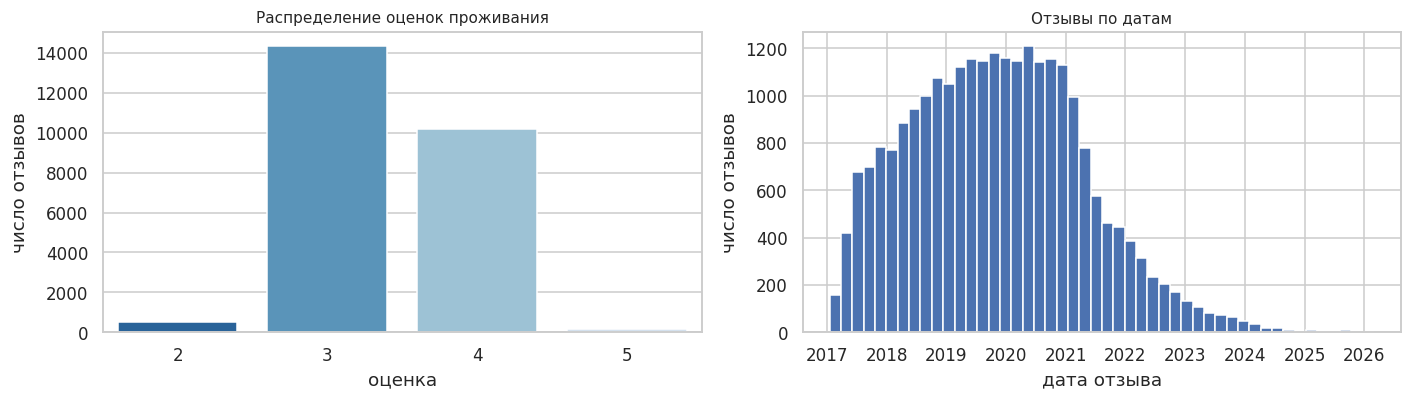

In [11]:
ratings = (
    reviews_raw["stay_rating"].value_counts().sort_index().to_frame("отзывов")
    .assign(**{"доля_%": lambda d: (d["отзывов"] / len(reviews_raw) * 100).round(2)})
)
ratings.columns.name = "stay_rating"
display(ratings)

review_dates = pd.to_datetime(reviews_raw["review_date"])
booking_dates = pd.to_datetime(bookings_raw["booking_date"])
periods = pd.DataFrame(
    [
        ["hotel_bookings.booking_date", booking_dates.min(), booking_dates.max()],
        ["hotel_reviews.review_date", review_dates.min(), review_dates.max()],
    ],
    columns=["поле", "минимум", "максимум"],
).set_index("поле")
display(periods)

display(reviews_raw["review_text"].str.len().describe().round(1).to_frame("длина_текста_символов"))
display(reviews_raw[["customer_id", "booking_id", "review_date", "stay_rating", "review_text"]].head(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.countplot(x=reviews_raw["stay_rating"], ax=axes[0], palette="Blues_r")
axes[0].set_title("Распределение оценок проживания", fontsize=10)
axes[0].set_xlabel("оценка")
axes[0].set_ylabel("число отзывов")
axes[1].hist(review_dates, bins=48, color="#4C72B0")
axes[1].set_title("Отзывы по датам", fontsize=10)
axes[1].set_xlabel("дата отзыва")
axes[1].set_ylabel("число отзывов")
fig.tight_layout()
plt.show()

#### Проверка связи таблиц: где прячется утечка целевой переменной

В `hotel_bookings` нет `customer_id`, поэтому единственный способ узнать клиента - подтянуть его из `hotel_reviews` по `booking_id`. Прежде чем так делать, проверяем, как наличие отзыва связано со статусом брони.

In [12]:
bookings_unique = bookings_raw.drop_duplicates()
reviews_per_booking = reviews_raw.groupby("booking_id").size()
leak_check = pd.crosstab(
    bookings_unique["booking_id"].map(reviews_per_booking).fillna(0).astype(int),
    bookings_unique["booking_status"],
)
leak_check.index.name = "отзывов по брони"
display(leak_check)

coverage = pd.DataFrame(
    [
        ["уникальных booking_id в бронированиях", bookings_unique["booking_id"].nunique()],
        ["из них есть в таблице отзывов", bookings_unique["booking_id"].isin(reviews_raw["booking_id"]).sum()],
        ["booking_id из отзывов, которых нет в бронированиях",
         int((~reviews_raw["booking_id"].isin(bookings_raw["booking_id"])).sum())],
        ["уникальных клиентов в отзывах", reviews_raw["customer_id"].nunique()],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(coverage)

booking_status,нет_отказа,отказ_брони
отзывов по брони,,
0,0,8850
1,18858,0
2,2776,0
3,229,0
4,20,0


,значение
показатель,
уникальных booking_id в бронированиях,30733
из них есть в таблице отзывов,21883
"booking_id из отзывов, которых нет в бронированиях",0
уникальных клиентов в отзывах,13429


#### Предобработка

Исправляем найденные дефекты функциями `clean_bookings` и `clean_reviews` из модуля `feature_pipeline`:

- удаляем полные дубли строк;
- делим на 100 значения `adult_count` вида 100/200/300 - это ошибка ввода лишних нулей;
- сводим опечатку `не выбрант` к категории `не выбран`;
- переводим нулевую стоимость брони в пропуск, чтобы её заполнил импьютер по медиане обучающей выборки;
- приводим даты к `datetime`, булевы поля - к 0/1 и создаём целевую переменную `is_cancelled`.

Исправления - доменные (ошибки ввода), они не используют статистику выборки, поэтому применяются до разделения на train/test и утечки не создают.

In [13]:
bookings = fp.clean_bookings(bookings_raw)
reviews = fp.clean_reviews(reviews_raw)

prep_report = pd.DataFrame(
    [
        ["строк в hotel_bookings", len(bookings_raw), len(bookings)],
        ["строк в hotel_reviews", len(reviews_raw), len(reviews)],
        ["adult_count >= 10", int((bookings_raw["adult_count"] >= 10).sum()),
         int((bookings["adult_count"] >= 10).sum())],
        ["категорий meal_plan", bookings_raw["meal_plan"].nunique(), bookings["meal_plan"].nunique()],
        ["пропусков в booking_value", int(bookings_raw["booking_value"].isna().sum()),
         int(bookings["booking_value"].isna().sum())],
    ],
    columns=["показатель", "до_предобработки", "после_предобработки"],
).set_index("показатель")
display(prep_report)

display(bookings[["adult_count", "booking_value"]].describe().T.round(2))
display(bookings["is_cancelled"].value_counts(normalize=True).round(4).to_frame("доля"))

,до_предобработки,после_предобработки
показатель,,
строк в hotel_bookings,35341,30733
строк в hotel_reviews,25177,25177
adult_count >= 10,2151,0
категорий meal_plan,5,4
пропусков в booking_value,0,1229


,count,mean,std,min,25%,50%,75%,max
adult_count,"30,733.0000",1.8000,0.7500,1.0000,1.0000,2.0000,2.0000,3.0000
booking_value,"29,504.0000","64,248.4400","41,683.1400","6,700.0000","46,900.0000","60,300.0000","89,000.0000","417,221.2000"


,доля
0,0.7120
1,0.2880


### Выводы по исследовательскому анализу

**Качество данных**

- **Пропусков нет ни в одной таблице** - все столбцы заполнены на 100%.
- В `hotel_bookings` **4 608 полных дублей строк** (13.0% таблицы): `booking_id` повторяется до четырёх раз, но внутри каждой группы дублей все 16 столбцов имеют ровно одно уникальное значение. Это технические копии, а не конфликт данных, поэтому дубли удалены: осталось **30 733 уникальных брони**.
- В `hotel_reviews` полных дублей нет, но есть **130 повторов пары `booking_id` + `review_date`**: один гость мог оставить по одной поездке несколько отзывов. Всего 25 177 отзывов на 21 883 брони от 13 429 клиентов.

**Аномалии и их исправление**

- `adult_count` принимает значения **100 (884 строки), 200 (872) и 300 (395)** - суммарно 2 151 запись, 6.09% таблицы. Столько взрослых в одном номере невозможно, а распределение этих значений повторяет распределение 1/2/3, то есть это ошибка ввода лишних нулей. Значения поделены на 100, после чего максимум `adult_count` стал равен 3.
- **1 421 бронь (4.02%) имеет нулевую стоимость** при минимальной ненулевой цене 6 700 руб. Доля отмен среди них 28.92% против 28.75% у остальных, то есть ноль не связан с целевой переменной и это незаполненное поле, а не бесплатное проживание. Нули переведены в пропуски и будут заполнены медианой обучающей выборки.
- В справочнике питания опечатка: категория **`не выбрант` (507 строк)** сведена к `не выбран`, число категорий уменьшилось с 5 до 4.
- Выбросы по правилу 1.5 IQR: `booking_value` - 1 006 наблюдений (2.85%, максимум 417 221 руб.), `weekend_nights` - 1 082 (3.06%), `previous_no_shows` - 2 137 (6.05%). Это правдоподобные значения (дорогие длительные брони и постоянные гости), поэтому они сохранены. Единственные выбросы, которые были ошибкой, - те самые 2 151 запись по `adult_count`.
- Стоимость брони почти всегда равна **6 700 руб. за ночь**: и первый квартиль, и медиана, и третий квартиль `price_per_night` совпадают. Тариф в данных практически постоянный, поэтому стоимость почти не несёт информации сверх длительности проживания.

**Целевая переменная и связи с признаками**

- Доля отмен - **28.76%** (10 164 отмены из 35 341). Дисбаланс умеренный, но заметный, поэтому accuracy неинформативна, а разбиение выборок делается со стратификацией.
- Сильнее всего с отменой связан **срок до заезда**: корреляция 0.282, средний срок у отменённых броней 132 дня против 88 у состоявшихся.
- **Канал продаж** разделяет клиентов лучше всех категорий: онлайн-бронирования отменяются в **41.42%** случаев, офлайн - в 28.29%, корпоративные - в **16.79%**.
- **История клиента работает монотонно**: без прошлых отмен - 25.23% отмен, с одной - 35.08%, с двумя - 45.38%, с тремя - 58.88%.
- **Число детей влияет немонотонно**: 31.84% отмен без детей, 15.85% с одним ребёнком и 46.18% с двумя. Признак стоит оставить в исходном виде, а не превращать в бинарный флаг.
- Тип номера и тип питания почти не различают классы: разброс долей отмен 25-30% при среднем 28.76%, причём крайние значения посчитаны на 7-10 бронях.

**Отзывы**

- Оценки лежат в диапазоне **от 2 до 5, оценки 1 в данных нет**; 56.94% отзывов имеют оценку 3, 40.35% - оценку 4. Тексты короткие: медиана 95 символов, максимум 225.
- Период отзывов (2017-01-17 - 2026-03-03) шире периода броней (2017-01-01 - 2025-10-22): часть отзывов относится к поездкам, которых нет среди дат бронирования.

**Главная находка: отзыв однозначно выдаёт статус брони**

Кросс-таблица «число отзывов по брони» против статуса не оставляет вариантов:

- у **8 850 броней отзывов нет, и все они отменены**;
- у **21 883 броней есть хотя бы один отзыв, и ни одна из них не отменена**.

Это логично: отзыв оставляет тот, кто заселился. Но практический вывод жёсткий: **связывать таблицы по клиенту нельзя**. `customer_id` есть только в отзывах, добраться до него можно лишь через `booking_id`, а сам факт такой связи равносилен ответу «бронь состоялась». Любая модель на таких признаках показала бы почти идеальное качество на истории и была бы бесполезна в проде, где статус ещё неизвестен.

**Итог:** данные полные и без пропусков, но требуют трёх исправлений (дубли, ошибка ввода в `adult_count`, нули в `booking_value`) и одного принципиального решения - объединять таблицы только по дате, без ключа клиента.

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

Правило объединения из задания - «к дате брони подтянуть ближайший предшествующий по дате отзыв». Реализуем его через `pd.merge_asof(direction="backward")`.

**Почему связь строится по времени, а не по клиенту.** В `hotel_bookings` нет `customer_id`; единственный путь к нему - таблица отзывов по `booking_id`. Но проверка выше показала: отзыв есть у всех состоявшихся броней и ни у одной отменённой. Значит, любой признак, полученный через связь по клиенту (включая сам факт «клиент найден»), однозначно определяет целевую переменную - это утечка, а не сигнал. Модель на таких признаках показала бы почти идеальное качество на исторических данных и не работала бы в проде, где статус брони ещё неизвестен.

Поэтому объединение выполняется только по дате: каждой брони достаётся последний отзыв, который был известен сети отелей на момент её оформления. Такой признак доступен в момент прогноза и утечки не создаёт.

In [14]:
data = fp.join_reviews(bookings, reviews)

join_report = pd.DataFrame(
    [
        ["строк до объединения", len(bookings)],
        ["строк после объединения", len(data)],
        ["броней без предшествующего отзыва", int(data["stay_rating"].isna().sum())],
        ["доля броней без отзыва, %", round(data["stay_rating"].isna().mean() * 100, 2)],
        ["медианный лаг «отзыв -> бронь», дней", data["review_lag_days"].median()],
        ["максимальный лаг «отзыв -> бронь», дней", data["review_lag_days"].max()],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(join_report)

# Контроль корректности asof-соединения: дата отзыва не может быть позже даты брони,
# а число строк должно совпасть с числом броней (дублирования при соединении нет).
assert len(data) == len(bookings)
assert (data["review_lag_days"].dropna() >= 0).all()

display(data[["booking_date", "review_date", "review_lag_days", "stay_rating", "review_text"]].head())

rating_vs_target = data.groupby("stay_rating")["is_cancelled"].agg(["size", "mean"])
rating_vs_target.columns = ["броней", "доля_отмен"]
rating_vs_target["доля_отмен_%"] = (rating_vs_target["доля_отмен"] * 100).round(2)
display(rating_vs_target.drop(columns="доля_отмен"))

,значение
показатель,
строк до объединения,"30,733.0000"
строк после объединения,"30,733.0000"
броней без предшествующего отзыва,175.0000
"доля броней без отзыва, %",0.5700
"медианный лаг «отзыв -> бронь», дней",0.0000
"максимальный лаг «отзыв -> бронь», дней",35.0000


,booking_date,review_date,review_lag_days,stay_rating,review_text
0,2017-01-01,NaT,NaN,NaN,
1,2017-01-01,NaT,NaN,NaN,
2,2017-01-01,NaT,NaN,NaN,
3,2017-01-01,NaT,NaN,NaN,
4,2017-01-01,NaT,NaN,NaN,


,броней,доля_отмен_%
stay_rating,,
2.0000,511,30.1400
3.0000,18034,28.5800
4.0000,11858,29.0000
5.0000,155,31.6100


**Выводы по объединению таблиц**

- Объединение выполнено через `pd.merge_asof(direction="backward")`: каждой брони достался последний отзыв, оставленный **до** даты её оформления.
- Число строк не изменилось - **30 733 до и после соединения**, дублирования при join нет (проверено `assert`).
- Отзыв нашёлся почти для всех броней: **без предшествующего отзыва осталось 175 записей (0.57%)** - это самые ранние брони января 2017 года, когда отзывов ещё не было. Их `stay_rating` и `review_lag_days` заполнит импьютер.
- Отзывы приходят плотно: **медианный лаг между отзывом и бронью - 0 дней**, максимальный - 35 дней. То есть подтянутый отзыв почти всегда свежий.
- Проверка на сигнал: доля отмен по подтянутой оценке лежит в узком коридоре **28.58-31.61%** при среднем уровне 28.80%, причём крайние значения посчитаны на 511 и 155 бронях. Связи между оценкой предыдущего гостя и отменой текущей брони нет.

**Итог:** соединение прошло корректно и без потери строк, но признаки из отзывов при честном (не создающем утечку) правиле объединения оказываются почти шумовыми. Это ожидаемо: отзыв относится к чужой поездке, а не к клиенту текущей брони.

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

Признаки собираются функцией `build_features` из `feature_pipeline.py`.

**Признаки по данным о брони:**

| Признак | Логика |
|---|---|
| `total_nights` | общая длительность проживания, сумма будних и выходных ночей |
| `weekend_share` | доля выходных ночей: отличает деловые поездки от отдыха |
| `guests_total` | общее число гостей, взрослые плюс дети |
| `price_per_night` | стоимость одной ночи, сопоставимая цена для броней разной длительности |
| `checkin_month`, `checkin_dayofweek` | месяц и день недели планируемого заезда, восстановлены из даты брони и срока до заезда |
| `booking_month`, `booking_year` | момент оформления брони |
| `season_group` | **категоризация сезонности**: высокий сезон (лето и декабрь), низкий (февраль, март, октябрь, ноябрь), средний - остальные месяцы |
| `lead_time_group` | **категоризация срока до заезда**: до месяца, 1-3 месяца, 3-6 месяцев, более полугода |
| `review_lag_days` | сколько дней прошло от последнего отзыва до оформления брони |

Пары признаков, из которых собраны производные, из набора убраны, чтобы не оставлять точные линейные зависимости: `weekday_nights` и `weekend_nights` заменены на `total_nights` + `weekend_share`, `adult_count` - на `guests_total` (вместе с сохранённым `child_count` это то же самое количество информации), `booking_value` - на `price_per_night`. `season_group` и `lead_time_group` - это категоризация исходных признаков, а не линейная комбинация, поэтому сосуществуют с ними.

**Признаки по текстам отзывов** создаёт `TfidfVectorizer` внутри препроцессора: 60 самых частотных слов длиной от трёх букв, встречающихся минимум в 50 отзывах. Векторизатор обучается только на обучающей выборке - иначе словарь и веса IDF впитали бы тестовые данные.

In [15]:
features = fp.build_features(data)
target = data[fp.TARGET].values

feature_overview = pd.DataFrame(
    [
        ["числовые", len(fp.NUMERIC_COLS), ", ".join(fp.NUMERIC_COLS)],
        ["категориальные", len(fp.CATEGORICAL_COLS), ", ".join(fp.CATEGORICAL_COLS)],
        ["текстовые", 1, fp.TEXT_COL],
    ],
    columns=["группа", "столбцов", "состав"],
).set_index("группа")
display(feature_overview)

display(features.head())
display(features[["total_nights", "weekend_share", "guests_total", "price_per_night",
                  "review_lag_days"]].describe().T.round(2))

new_cat_rates = []
for column in ["season_group", "lead_time_group"]:
    grouped = pd.Series(target, index=features.index).groupby(features[column]).agg(["size", "mean"])
    grouped.columns = ["броней", "доля_отмен"]
    grouped["доля_отмен_%"] = (grouped["доля_отмен"] * 100).round(2)
    grouped = grouped.drop(columns="доля_отмен").reset_index().rename(columns={column: "значение"})
    grouped.insert(0, "признак", column)
    new_cat_rates.append(grouped)
display(pd.concat(new_cat_rates, ignore_index=True).set_index(["признак", "значение"]))

,столбцов,состав
группа,,
числовые,17,"days_until_checkin, total_nights, weekend_shar..."
категориальные,5,"sales_channel, meal_plan, room_type, season_gr..."
текстовые,1,review_text


,days_until_checkin,total_nights,weekend_share,guests_total,child_count,price_per_night,previous_cancellations,previous_no_shows,customer_special_requests,returning_customer,parking_included,checkin_month,checkin_dayofweek,booking_month,booking_year,stay_rating,review_lag_days,sales_channel,meal_plan,room_type,season_group,lead_time_group,review_text
0,79,11,0.1818,2,0,"6,700.0000",1,1,2,1,0,3,1,1,2017,NaN,NaN,офлайн_бронирование,тип_питания_1,тип_1,низкий_сезон,1-3_месяца,
1,87,16,0.2500,2,0,"10,397.7125",0,0,0,0,0,3,2,1,2017,NaN,NaN,онлайн_бронирование,тип_питания_2,тип_1,низкий_сезон,1-3_месяца,
2,85,10,0.2000,3,0,"8,900.0000",0,0,1,0,0,3,0,1,2017,NaN,NaN,онлайн_бронирование,тип_питания_1,тип_1,низкий_сезон,1-3_месяца,
3,63,1,0.0000,3,0,"6,700.0000",0,0,1,0,0,3,6,1,2017,NaN,NaN,корпоративное_бронирование,тип_питания_1,тип_4,низкий_сезон,1-3_месяца,
4,124,10,0.2000,5,2,"6,700.0000",0,0,0,0,0,5,4,1,2017,NaN,NaN,онлайн_бронирование,тип_питания_2,тип_2,средний_сезон,3-6_месяцев,


,count,mean,std,min,25%,50%,75%,max
total_nights,"30,733.0000",8.4900,4.7200,1.0000,5.0000,8.0000,11.0000,21.0000
weekend_share,"30,733.0000",0.1900,0.1100,0.0000,0.0000,0.2200,0.2900,0.2900
guests_total,"30,733.0000",2.1600,0.9500,1.0000,1.0000,2.0000,3.0000,5.0000
price_per_night,"29,504.0000","7,564.2900","2,167.8900","6,700.0000","6,700.0000","6,700.0000","6,700.0000","19,995.3500"
review_lag_days,"30,558.0000",0.0300,0.5900,0.0000,0.0000,0.0000,0.0000,35.0000


броней  доля_отмен_%
признак         значение                            
season_group    высокий_сезон    10346       28.3600
                низкий_сезон     10112       28.3900
                средний_сезон    10275       29.6400
lead_time_group 1-3_месяца        8634       25.6800
                3-6_месяцев       9646       26.7500
                более_полугода    5351       56.7900
                до_месяца         7102       14.2800

**Выводы по созданным признакам**

- Создано **девять признаков по данным о брони** плюс два признака из отзывов; итоговый набор - 17 числовых, 5 категориальных и один текстовый столбец.
- Самый сильный из новых - **категоризация срока до заезда**: брони, оформленные более чем за полгода, отменяются в **56.79%** случаев, а оформленные меньше чем за месяц - в **14.28%**. Разрыв в 42.5 процентных пункта - это больше, чем даёт любой исходный категориальный признак.
- **Сезонность оказалась слабым признаком**: 28.36% отмен в высокий сезон, 28.39% в низкий и 29.64% в средний. Спрос на отмену брони в этих данных от времени года практически не зависит, но признак оставлен - деревья используют его во взаимодействиях с другими.
- `price_per_night` почти константа (медиана 6 700 руб. при межквартильном размахе, равном нулю) - следствие фиксированного тарифа в данных.
- `weekend_share` в среднем 0.19, `total_nights` - в среднем 8.5 ночи, `guests_total` - 2.16 гостя на бронь.
- Из набора убраны исходные составляющие производных признаков: `weekday_nights` и `weekend_nights` (заменены парой `total_nights` + `weekend_share`), `adult_count` (заменён на `guests_total`), `booking_value` (заменён на `price_per_night`). Так в наборе не остаётся точных линейных зависимостей.

**Итог:** ключевую информацию несут срок до заезда и его категоризация, история отмен клиента и канал продаж; признаки из отзывов добавлены по требованию задания, но большого вклада от них ждать не стоит.

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

Проверяем итоговую таблицу перед моделированием: состав столбцов, пропуски, типы и связь числовых признаков с целевой переменной.

"итоговая таблица: 30733 строк, 23 столбцов",тип,пропусков,доля_пропусков_%,уникальных
days_until_checkin,int64,0,0.0000,79
total_nights,int64,0,0.0000,16
weekend_share,float64,0,0.0000,9
guests_total,int64,0,0.0000,5
child_count,int64,0,0.0000,3
price_per_night,float64,1229,4.0000,1735
previous_cancellations,int64,0,0.0000,6
previous_no_shows,int64,0,0.0000,6
customer_special_requests,int64,0,0.0000,6
returning_customer,int64,0,0.0000,2


,корреляция_с_отменой
days_until_checkin,0.2860
previous_cancellations,0.1394
weekend_share,-0.1047
total_nights,-0.0767
child_count,-0.0465
booking_year,-0.0310
previous_no_shows,-0.0310
guests_total,-0.0271
returning_customer,-0.0106
checkin_dayofweek,-0.0103


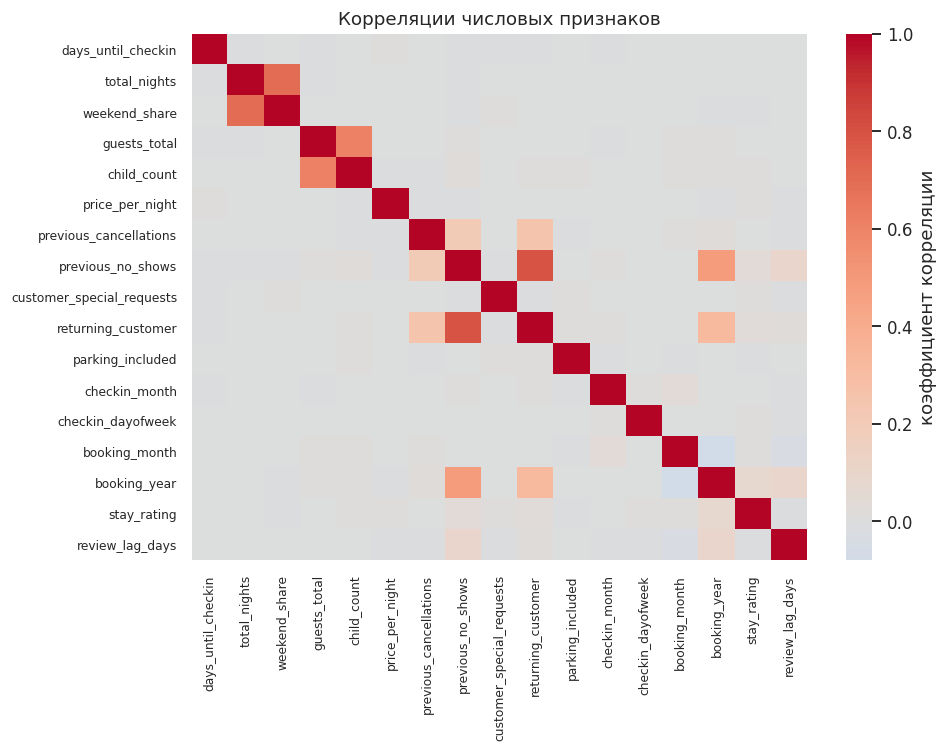

,корреляция


In [16]:
final_report = pd.DataFrame({
    "тип": features.dtypes.astype(str),
    "пропусков": features.isna().sum(),
    "доля_пропусков_%": (features.isna().mean() * 100).round(2),
    "уникальных": features.nunique(),
})
final_report.columns.name = f"итоговая таблица: {features.shape[0]} строк, {features.shape[1]} столбцов"
display(final_report)

corr_final = (
    features[fp.NUMERIC_COLS]
    .assign(is_cancelled=target)
    .corr()["is_cancelled"]
    .drop("is_cancelled")
    .sort_values(key=abs, ascending=False)
    .round(4)
    .to_frame("корреляция_с_отменой")
)
display(corr_final)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(features[fp.NUMERIC_COLS].corr().round(2), cmap="coolwarm", center=0,
            annot=False, ax=ax, cbar_kws={"label": "коэффициент корреляции"})
ax.set_title("Корреляции числовых признаков")
ax.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

# Пары признаков с корреляцией выше 0.8 могли бы дублировать друг друга - проверяем явно.
corr_matrix = features[fp.NUMERIC_COLS].corr().abs()
pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
strong_pairs = pairs[pairs > 0.8].sort_values(ascending=False).round(3).to_frame("корреляция")
strong_pairs.index.names = ["признак_1", "признак_2"]
display(strong_pairs if len(strong_pairs) else pd.DataFrame({"корреляция": []}))

**Выводы по итоговой таблице**

- Итоговая таблица - **30 733 строки и 23 столбца** (17 числовых, 5 категориальных, 1 текстовый).
- Пропуски остались только там, где они осмысленны: `price_per_night` - 4.00% (нулевая стоимость, переведённая в пропуск), `stay_rating` и `review_lag_days` - по 0.57% (брони без предшествующего отзыва). Все они заполняются медианой обучающей выборки внутри препроцессора, то есть без утечки.
- Связь с целевой переменной ожидаемо возглавляет **`days_until_checkin` (0.286)**, далее `previous_cancellations` (0.139), `weekend_share` (-0.1047) и `total_nights` (-0.0767). Остальные числовые признаки коррелируют с отменой слабее 0.05.
- **Пар признаков с корреляцией выше 0.8 нет** - производные признаки не продублировали исходные, мультиколлинеарности в наборе не осталось.

**Итог:** таблица готова к моделированию. Линейной связи с целевой переменной мало (максимум 0.29), поэтому ставка делается на ансамбли деревьев, которые улавливают нелинейности и взаимодействия.

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

#### Разделение выборок и схема кросс-валидации

Данные делятся на train / calibration / test в пропорции 60 / 20 / 20 со стратификацией по целевой переменной. Внутри обучающей выборки работает `StratifiedShuffleSplit` с тремя фолдами и валидационной частью в 2 000 объектов - размер задан требованиями задания.

Распределение целевой переменной в тестовой выборке до этапа 3 не раскрываем: это отложенная выборка, и её статистики - такая же утечка, как обучение на ней. Стратификация гарантирует ту же долю отмен, что и в обучающей части.

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    features, target, test_size=0.4, random_state=RANDOM_STATE, stratify=target
)
X_cal, X_test, y_cal, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

split_report = pd.DataFrame(
    [
        ["train", len(X_train), round(len(X_train) / len(features) * 100, 1), round(y_train.mean() * 100, 2)],
        ["calibration", len(X_cal), round(len(X_cal) / len(features) * 100, 1), round(y_cal.mean() * 100, 2)],
        ["test", len(X_test), round(len(X_test) / len(features) * 100, 1), np.nan],
    ],
    columns=["выборка", "строк", "доля_%", "доля_отмен_%"],
).set_index("выборка")
split_report.columns.name = "доля отмен теста закрыта до этапа 3"
display(split_report)

# Препроцессор обучается только на train, остальные выборки только преобразуются.
preprocessor = fp.make_preprocessor()
A_train = preprocessor.fit_transform(X_train, y_train)
A_cal = preprocessor.transform(X_cal)
A_test = preprocessor.transform(X_test)
feature_names = fp.get_feature_names(preprocessor)

display(pd.DataFrame(
    [["train", A_train.shape], ["calibration", A_cal.shape], ["test", A_test.shape]],
    columns=["выборка", "размерность после препроцессора"],
).set_index("выборка"))
display(pd.Series(feature_names[-12:], name="последние TF-IDF признаки").to_frame())

доля отмен теста закрыта до этапа 3,строк,доля_%,доля_отмен_%
выборка,,,
train,18439,60.0000,28.8000
calibration,6147,20.0000,28.7900
test,6147,20.0000,NaN


,размерность после препроцессора
выборка,
train,"(18439, 98)"
calibration,"(6147, 98)"
test,"(6147, 98)"


,последние TF-IDF признаки
0,tfidf_ресторане
1,tfidf_система
2,tfidf_скучно
3,tfidf_спасал
4,tfidf_справлялся
5,tfidf_трансфер
6,tfidf_тяжело
7,tfidf_удобные
8,tfidf_уютная
9,tfidf_холодно


#### Базовые сценарии

Прежде чем сравнивать модели, фиксируем две константные стратегии - они задают планку, ниже которой модель бессмысленна. «Никогда не предсказывать отмену» - это ровно текущее положение дел, то есть $IR_{до}$.

In [18]:
baselines = []
for name, prediction in [
    ("все брони считаем состоявшимися", np.zeros_like(y_cal)),
    ("все брони считаем отменами", np.ones_like(y_cal)),
]:
    metrics = fp.business_metrics(y_cal, prediction)
    baselines.append([name, metrics["IR_after"], metrics["IR"], metrics["IR_rel_%"]])
baselines = pd.DataFrame(baselines, columns=["сценарий", "IR_после", "IR", "IR_отн_%"]).set_index("сценарий")
baselines.columns.name = "калибровочная выборка"
display(baselines.round(2))

break_even = fp.break_even_threshold()
display(pd.DataFrame(
    [
        ["выигрыш от верного прогноза отмены, руб.", fp.PER_REBOOKING + fp.LOST_REV],
        ["потеря от ложной тревоги, руб.", fp.AVG_REV + fp.COST_FP],
        ["порог безубыточности", round(break_even, 4)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель"))

калибровочная выборка,IR_после,IR,IR_отн_%
сценарий,,,
все брони считаем состоявшимися,168151500,0,0.0000
все брони считаем отменами,49011000,-119140500,-70.8500


,значение
показатель,
"выигрыш от верного прогноза отмены, руб.","109,500.0000"
"потеря от ложной тревоги, руб.","71,500.0000"
порог безубыточности,0.3950


#### Турнир моделей

Сравниваем три библиотеки: Random Forest как ансамбль без бустинга и два градиентных бустинга - LightGBM и CatBoost. Все модели получают одинаковые строки и одинаковый формат признаков (one-hot плюс TF-IDF), число потоков зафиксировано, чтобы сравнивать алгоритмы, а не настройки многопоточности.

Optuna подбирает по 4-6 гиперпараметров на модель. Целевая функция - средний по трём фолдам IR, максимизированный по сетке порогов внутри фолда: разные семейства моделей дают вероятности разного масштаба, и оценка в одной фиксированной точке сравнивала бы их калибровку, а не качество ранжирования. Итоговые честные значения берутся позже с калибровочной и тестовой выборок.

Масштабирование признаков не применяется: все три модели - деревья, они инвариантны к монотонным преобразованиям, и стандартизация ничего бы не изменила.

In [19]:
cv = StratifiedShuffleSplit(n_splits=3, test_size=2000, random_state=RANDOM_STATE)
THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.01), 2)


def make_model(name, params):
    """Создаёт модель нужного семейства с заданными гиперпараметрами."""
    if name == "RandomForest":
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS,
                                      class_weight="balanced", **params)
    if name == "LightGBM":
        return lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, **params)
    return CatBoostClassifier(random_seed=RANDOM_STATE, thread_count=N_JOBS,
                              verbose=0, **params)


SEARCH_SPACES = {
    "RandomForest": lambda trial: dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 600, step=100),
        max_depth=trial.suggest_int("max_depth", 6, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 40),
        max_features=trial.suggest_float("max_features", 0.2, 0.9),
    ),
    "LightGBM": lambda trial: dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 900, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 80),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    ),
    "CatBoost": lambda trial: dict(
        iterations=trial.suggest_int("iterations", 200, 800, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        depth=trial.suggest_int("depth", 4, 9),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
    ),
}


def cross_validate_ir(name, params):
    """Средние по фолдам IR и ROC-AUC для одной конфигурации."""
    fold_ir, fold_auc = [], []
    for train_idx, valid_idx in cv.split(A_train, y_train):
        model = make_model(name, params)
        model.fit(A_train[train_idx], y_train[train_idx])
        proba = model.predict_proba(A_train[valid_idx])[:, 1]
        scan = fp.threshold_scan(y_train[valid_idx], proba, THRESHOLD_GRID)
        fold_ir.append(scan["IR"].max())
        fold_auc.append(roc_auc_score(y_train[valid_idx], proba))
    return float(np.mean(fold_ir)), float(np.mean(fold_auc))


N_TRIALS = 20
tournament_rows, best_configs = [], {}
for model_name, space in SEARCH_SPACES.items():
    def objective(trial, model_name=model_name, space=space):
        params = space(trial)
        mean_ir, mean_auc = cross_validate_ir(model_name, params)
        trial.set_user_attr("roc_auc", mean_auc)
        return mean_ir

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=model_name,
    )
    started = time.time()
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    tournament_rows.append({
        "модель": model_name,
        "IR_cv": round(study.best_value, 1),
        "ROC_AUC_cv": round(study.best_trial.user_attrs["roc_auc"], 4),
        "время_с": round(time.time() - started, 1),
        "лучшие_параметры": study.best_params,
    })
    best_configs[model_name] = study.best_params

tournament = pd.DataFrame(tournament_rows).sort_values("IR_cv", ascending=False).set_index("модель")
tournament.columns.name = f"кросс-валидация: 3 фолда по 2 000 объектов, {N_TRIALS} испытаний Optuna"
display(tournament)

best_model_name = tournament.index[0]
best_params = best_configs[best_model_name]
display(pd.Series(best_params, name=f"гиперпараметры победителя: {best_model_name}").to_frame())

"кросс-валидация: 3 фолда по 2 000 объектов, 20 испытаний Optuna",IR_cv,ROC_AUC_cv,время_с,лучшие_параметры
модель,,,,
CatBoost,"22,758,000.0000",0.8092,235.8000,"{'iterations': 600, 'learning_rate': 0.0151874..."
LightGBM,"21,924,333.3000",0.8051,95.8000,"{'n_estimators': 700, 'learning_rate': 0.01020..."
RandomForest,"21,560,833.3000",0.7986,"2,361.8000","{'n_estimators': 300, 'max_depth': 7, 'min_sam..."


,гиперпараметры победителя: CatBoost
iterations,600.0000
learning_rate,0.0152
depth,5.0000
l2_leaf_reg,4.2973


**Выводы по турниру моделей**

| Модель | IR на кросс-валидации | ROC-AUC | Время подбора |
|---|---|---|---|
| **CatBoost** | **22 758 000 руб.** | **0.8092** | 236 с |
| LightGBM | 21 924 333 руб. | 0.8051 | 96 с |
| Random Forest | 21 560 833 руб. | 0.7986 | 2 362 с |

- **Победитель - CatBoost** с параметрами `iterations = 600`, `learning_rate = 0.0152`, `depth = 5`, `l2_leaf_reg = 4.2973`. Все четыре значения лежат внутри сетки поиска, на её краю победитель не оказался.
- Разрыв между библиотеками небольшой: **5.6% по IR и 0.011 по ROC-AUC** между первым и третьим местом, между CatBoost и LightGBM - всего 3.8%. Все три семейства упираются в один и тот же потолок сигнала в данных, а не в устройство алгоритма.
- По стоимости подбора разница принципиальная: Random Forest потребовал **в 10 раз больше времени, чем CatBoost, и при этом проиграл** - его лучшая конфигурация состоит из 300 деревьев глубины 7, тогда как бустинг набирает то же качество на 600 неглубоких деревьях.
- Обе базовые стратегии проигрывают модели: «все брони считаются состоявшимися» - это ровно текущее положение дел (IR = 0 по определению), «все брони считаются отменами» даёт **-70.85%** к доходу. Порог безубыточности, следующий из матрицы стоимостей, равен **0.395**: отмену выгодно прогнозировать, если её вероятность выше 39.5%.

**Итог:** для дальнейшей работы зафиксирован CatBoost - он дал лучший IR при вдесятеро меньшем времени обучения, чем ближайший по качеству конкурент по времени.

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

Калибруем победителя на полной обучающей выборке: `CalibratedClassifierCV` с тремя фолдами внутри train обучает изотоническую регрессию поверх предсказаний, а на выходе усредняет три откалиброванные копии модели.

Схема выбрана так, чтобы калибровочная выборка осталась чистой: калибратор учится на train, а калибровочная выборка используется только для оценки качества калибровки и поиска порога. Если бы калибратор обучался и проверялся на одних и тех же данных, и Brier, и порог получились бы оптимистичными.

калибровочная выборка,Brier,ROC_AUC,PR_AUC,максимум_IR
модель,,,,
без калибровки,0.1505,0.8113,0.6600,66685500
после калибровки,0.1502,0.8106,0.6564,66352500


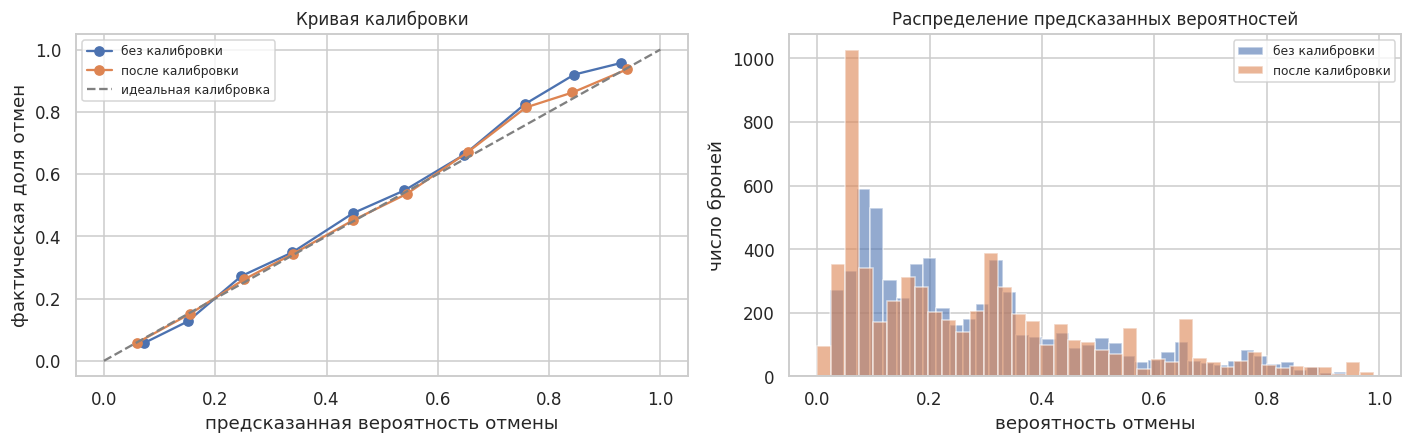

In [20]:
base_model = make_model(best_model_name, best_params)
base_model.fit(A_train, y_train)

calibrated_model = CalibratedClassifierCV(
    base_estimator=make_model(best_model_name, best_params), cv=3, method="isotonic"
)
calibrated_model.fit(A_train, y_train)

proba_cal_base = base_model.predict_proba(A_cal)[:, 1]
proba_cal_calibrated = calibrated_model.predict_proba(A_cal)[:, 1]

calibration_quality = pd.DataFrame(
    [
        ["без калибровки",
         brier_score_loss(y_cal, proba_cal_base),
         roc_auc_score(y_cal, proba_cal_base),
         average_precision_score(y_cal, proba_cal_base),
         fp.threshold_scan(y_cal, proba_cal_base, THRESHOLD_GRID)["IR"].max()],
        ["после калибровки",
         brier_score_loss(y_cal, proba_cal_calibrated),
         roc_auc_score(y_cal, proba_cal_calibrated),
         average_precision_score(y_cal, proba_cal_calibrated),
         fp.threshold_scan(y_cal, proba_cal_calibrated, THRESHOLD_GRID)["IR"].max()],
    ],
    columns=["модель", "Brier", "ROC_AUC", "PR_AUC", "максимум_IR"],
).set_index("модель")
calibration_quality["Brier"] = calibration_quality["Brier"].round(6)
calibration_quality[["ROC_AUC", "PR_AUC"]] = calibration_quality[["ROC_AUC", "PR_AUC"]].round(6)
calibration_quality.columns.name = "калибровочная выборка"
display(calibration_quality)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for label, proba in [("без калибровки", proba_cal_base), ("после калибровки", proba_cal_calibrated)]:
    fraction, mean_predicted = calibration_curve(y_cal, proba, n_bins=10)
    axes[0].plot(mean_predicted, fraction, marker="o", label=label)
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="идеальная калибровка")
axes[0].set_title("Кривая калибровки", fontsize=11)
axes[0].set_xlabel("предсказанная вероятность отмены")
axes[0].set_ylabel("фактическая доля отмен")
axes[0].legend(fontsize=8)

axes[1].hist(proba_cal_base, bins=40, alpha=0.6, label="без калибровки")
axes[1].hist(proba_cal_calibrated, bins=40, alpha=0.6, label="после калибровки")
axes[1].set_title("Распределение предсказанных вероятностей", fontsize=11)
axes[1].set_xlabel("вероятность отмены")
axes[1].set_ylabel("число броней")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Выводы по калибровке**

| Модель | Brier | ROC-AUC | PR-AUC | Максимум IR |
|---|---|---|---|---|
| без калибровки | 0.1505 | 0.8113 | 0.6600 | 66 685 500 руб. |
| после калибровки | 0.1502 | 0.8106 | 0.6564 | 66 352 500 руб. |

- Изотоническая калибровка на трёх фолдах обучающей выборки **улучшила Brier примерно на 0.2%** (0.1505 против 0.1502). Это ожидаемо: CatBoost с логистической функцией потерь и так выдаёт близкие к честным вероятности, что видно и на кривой калибровки - обе линии идут вдоль диагонали.
- Ранжирующая способность практически не изменилась: ROC-AUC 0.8113 против 0.8106, PR-AUC 0.6600 против 0.6564. Максимум IR на калибровочной выборке отличается на 0.5% (66.69 против 66.35 млн руб.).
- Практическая польза калибровки здесь не в приросте метрики, а в **интерпретируемости порога**: после калибровки значение 0.38 действительно означает «в среднем 38 таких броней из 100 будут отменены», и порог можно осмысленно сравнивать с порогом безубыточности 0.395.

**Итог:** калибровка не ухудшила модель и сделала её вероятности пригодными для бизнес-решений; дальше работаем с откалиброванной версией.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

Порог ищем по калибровочной выборке: перебираем сетку и выбираем значение, дающее максимальный IR. Сетку строим по квантилям предсказанных вероятностей плюс равномерный шаг - так узлы попадают туда, где реально лежат предсказания.

Рядом с оптимумом по деньгам смотрим порог, при котором выполняется цель заказчика по доле отмен (10%): это разные точки, и разницу между ними надо показать бизнесу явно.

,threshold,TP,FP,FN,TN,IR_after,IR,IR_rel_%,cancel_after_%,occupancy_after_%
0,0.0390,1765,4273,5,104,55899500,-112252000,-66.7560,0.0810,30.4050
4,0.0520,1750,3949,20,428,77423000,-90728500,-53.9560,0.3250,35.4320
8,0.0600,1709,3304,61,1073,119051000,-49100500,-29.2000,0.9920,45.2580
12,0.0740,1686,2983,84,1394,139484000,-28667500,-17.0490,1.3670,50.1060
16,0.0900,1668,2680,102,1697,159177500,-8974000,-5.3370,1.6590,54.7420
20,0.1200,1653,2535,117,1842,167902500,-249000,-0.1480,1.9030,56.8570
24,0.1400,1634,2388,136,1989,176332500,8181000,4.8650,2.2120,58.9390
28,0.1600,1597,2181,173,2196,187081500,18930000,11.2580,2.8140,61.7050
32,0.1800,1551,1978,219,2399,196559000,28407500,16.8940,3.5630,64.2590
36,0.2000,1506,1773,264,2604,206289000,38137500,22.6800,4.2950,66.8620


,threshold,TP,FP,FN,TN,IR_after,IR,IR_rel_%,cancel_after_%,occupancy_after_%,цель_по_отменам_выполнена
комментарий,,,,,,,,,,,
цель по доле отмен <= 10%,0.3300,1201,991,569,3386,228804500,60653000,36.0700,9.2570,74.6220,True
максимум IR,0.3800,1033,654,737,3723,234504000,66352500,39.4600,11.9900,77.3710,False


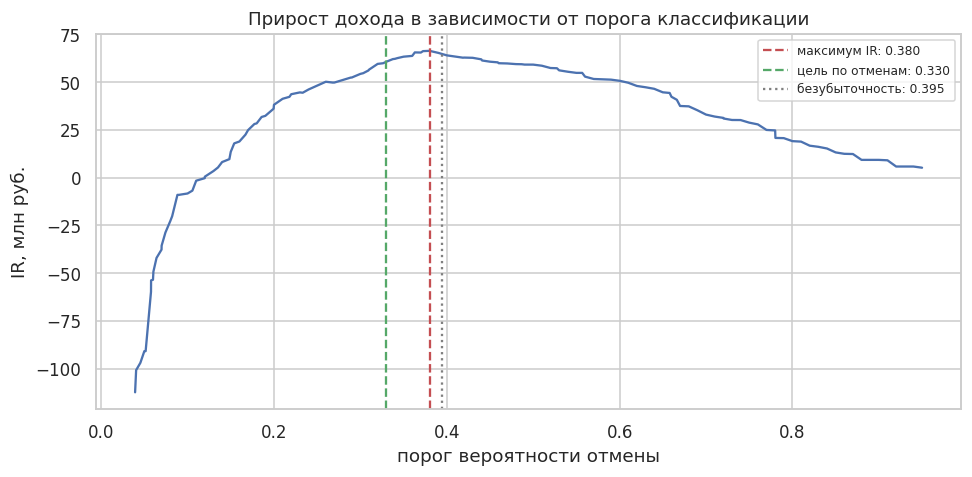

In [21]:
quantile_grid = np.quantile(proba_cal_calibrated, np.linspace(0.02, 0.98, 49))
threshold_grid = np.unique(np.round(np.concatenate([quantile_grid, THRESHOLD_GRID]), 4))
threshold_table = fp.threshold_scan(y_cal, proba_cal_calibrated, threshold_grid)

best_threshold = float(threshold_table.loc[threshold_table["IR"].idxmax(), "threshold"])
target_rows = threshold_table[threshold_table["cancel_after_%"] <= 10.0]
threshold_cancel_goal = float(target_rows.loc[target_rows["IR"].idxmax(), "threshold"])

display(threshold_table.iloc[::4].round(3))

selected = threshold_table[threshold_table["threshold"].isin(
    [best_threshold, threshold_cancel_goal, round(break_even, 4)]
)].copy()
selected["комментарий"] = np.where(
    selected["threshold"] == best_threshold, "максимум IR",
    np.where(selected["threshold"] == threshold_cancel_goal,
             "цель по доле отмен <= 10%", "порог безубыточности"),
)
selected["цель_по_отменам_выполнена"] = selected["cancel_after_%"] <= 10.0
display(selected.round(3).set_index("комментарий"))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(threshold_table["threshold"], threshold_table["IR"] / 1e6, color="#4C72B0")
ax.axvline(best_threshold, color="#C44E52", linestyle="--",
           label=f"максимум IR: {best_threshold:.3f}")
ax.axvline(threshold_cancel_goal, color="#55A868", linestyle="--",
           label=f"цель по отменам: {threshold_cancel_goal:.3f}")
ax.axvline(break_even, color="grey", linestyle=":", label=f"безубыточность: {break_even:.3f}")
ax.set_title("Прирост дохода в зависимости от порога классификации")
ax.set_xlabel("порог вероятности отмены")
ax.set_ylabel("IR, млн руб.")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Выводы по порогу классификации**

- Максимум IR на калибровочной выборке достигается при пороге **0.380**: IR = 66 352 500 руб., относительный IR **+39.46%**, доля отмен после внедрения 11.99%, загрузка 77.37%.
- Найденный порог **почти совпал с порогом безубыточности 0.395**, посчитанным аналитически из матрицы стоимостей. Это хороший знак: оптимум определяется экономикой задачи, а не случайными особенностями выборки, и кривая IR вокруг него пологая - в диапазоне порогов 0.363-0.390 IR отличается от максимума не более чем на 1.6%.
- **Цель заказчика по доле отмен требует другого порога.** При 0.380 доля отмен составляет 11.99% - выше требуемых 10%. Ограничение выполняется начиная с порога **0.330**: доля отмен 9.26%, но IR падает до +36.07%, то есть на 3.4 процентных пункта.
- Крайние пороги наглядно показывают цену ошибок: при 0.039 модель ловит почти все отмены (1 765 из 1 770), но 4 273 ложные тревоги обнуляют выгоду и уводят IR в минус на 66.8%.

**Итог:** зафиксирован порог **0.380** как решение задачи оптимизации IR. Порог 0.330 сохранён как управленческая альтернатива - он выполняет цель по доле отмен ценой 3.4 п.п. относительного IR.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

Сравниваем матрицы ошибок и IR на калибровочной и тестовой выборках при одном и том же пороге. Расхождение показывает, переносится ли решение на новые данные или порог подогнан под калибровочную выборку.

порог 0.380,калибровочная,тестовая,расхождение_%
n,"6,147.0000","6,147.0000",0.0000
TP,"1,033.0000","1,053.0000",1.9361
FP,654.0000,697.0000,6.5749
FN,737.0000,717.0000,-2.7137
TN,"3,723.0000","3,680.0000",-1.1550
IR_before,"168,151,500.0000","168,151,500.0000",0.0000
IR_after,"234,504,000.0000","233,619,500.0000",-0.3772
IR,"66,352,500.0000","65,468,000.0000",-1.3330
IR_rel_%,39.4600,38.9339,-1.3330
cancel_before_%,28.7945,28.7945,0.0000


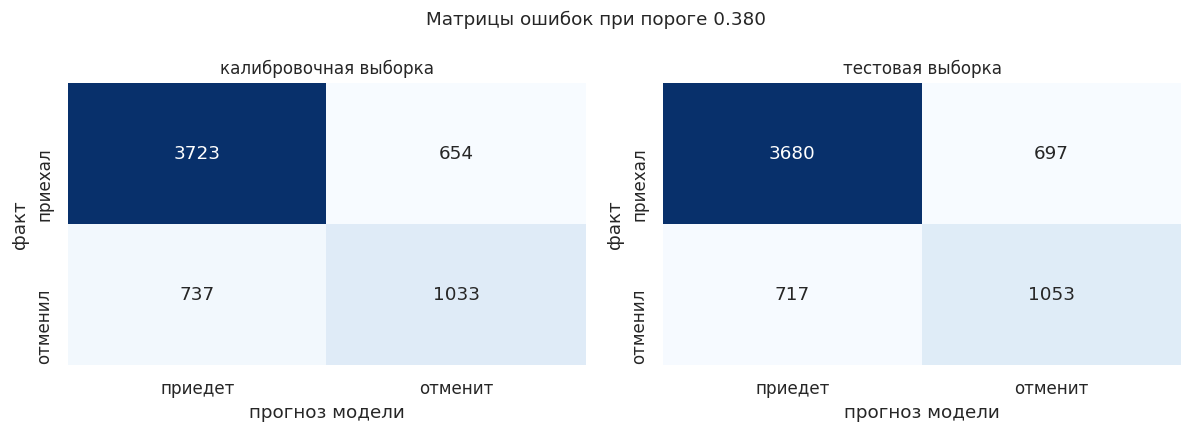

              precision    recall  f1-score   support

  нет_отказа       0.84      0.84      0.84      4377
 отказ_брони       0.60      0.59      0.60      1770

    accuracy                           0.77      6147
   macro avg       0.72      0.72      0.72      6147
weighted avg       0.77      0.77      0.77      6147



In [22]:
proba_test = calibrated_model.predict_proba(A_test)[:, 1]
pred_cal = (proba_cal_calibrated >= best_threshold).astype(int)
pred_test = (proba_test >= best_threshold).astype(int)

metrics_cal = fp.business_metrics(y_cal, pred_cal)
metrics_test = fp.business_metrics(y_test, pred_test)

stability = pd.DataFrame({"калибровочная": metrics_cal, "тестовая": metrics_test})
stability.loc["ROC_AUC"] = [roc_auc_score(y_cal, proba_cal_calibrated), roc_auc_score(y_test, proba_test)]
stability.loc["PR_AUC"] = [average_precision_score(y_cal, proba_cal_calibrated),
                           average_precision_score(y_test, proba_test)]
stability.loc["recall_отмен"] = [metrics_cal["TP"] / (metrics_cal["TP"] + metrics_cal["FN"]),
                                 metrics_test["TP"] / (metrics_test["TP"] + metrics_test["FN"])]
stability.loc["precision_отмен"] = [metrics_cal["TP"] / (metrics_cal["TP"] + metrics_cal["FP"]),
                                    metrics_test["TP"] / (metrics_test["TP"] + metrics_test["FP"])]
stability.loc["IR_на_бронь_руб"] = [metrics_cal["IR"] / metrics_cal["n"],
                                    metrics_test["IR"] / metrics_test["n"]]
stability["расхождение_%"] = (
    (stability["тестовая"] - stability["калибровочная"]) / stability["калибровочная"].abs() * 100
)
stability.columns.name = f"порог {best_threshold:.3f}"
display(stability.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, y_true, y_pred) in zip(
    axes,
    [("калибровочная выборка", y_cal, pred_cal), ("тестовая выборка", y_test, pred_test)],
):
    matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["приедет", "отменит"], yticklabels=["приехал", "отменил"])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("прогноз модели")
    ax.set_ylabel("факт")
fig.suptitle(f"Матрицы ошибок при пороге {best_threshold:.3f}", fontsize=12)
fig.tight_layout()
plt.show()

print(classification_report(y_test, pred_test, target_names=["нет_отказа", "отказ_брони"]))

**Выводы о стабильности модели**

| Показатель | Калибровочная | Тестовая | Расхождение |
|---|---|---|---|
| TP / FP / FN / TN | 1 033 / 654 / 737 / 3 723 | 1 053 / 697 / 717 / 3 680 | до 6.6% |
| IR | 66 352 500 руб. | 65 468 000 руб. | -1.33% |
| Относительный IR | +39.46% | +38.93% | -1.33% |
| ROC-AUC | 0.8106 | 0.8104 | -0.02% |
| PR-AUC | 0.6564 | 0.6578 | +0.21% |
| Recall отмен | 0.5836 | 0.5949 | +1.94% |
| Precision отмен | 0.6123 | 0.6017 | -1.73% |

- **Модель стабильна**: расхождение по IR между калибровочной и тестовой выборками составляет **1.33%**, по ROC-AUC - 0.02%. Порог, подобранный на калибровочной выборке, переносится на тест без потери качества.
- Структура ошибок тоже совпадает: на тесте модель ловит 1 053 отмены из 1 770 (recall 0.59) при 697 ложных тревогах на 4 377 состоявшихся броней (доля ложных тревог 15.9%). Точность по классу отмен - 0.60.
- В пересчёте на одну бронь модель приносит **10 794 руб. на калибровочной выборке и 10 650 руб. на тестовой** - разница 1.3%. Нормировка важна: сравнивать суммарный IR между выборками разного размера было бы некорректно, здесь выборки равны по 6 147 броней.
- Слабое место видно в отчёте классификации: по классу `отказ_брони` f1 = 0.60 против 0.84 у класса `нет_отказа`. Модель уверенно распознаёт тех, кто приедет, и заметно хуже - тех, кто отменит. Именно это ограничивает экономический эффект.

**Итог:** переобучения нет, метрики калибровочной и тестовой выборок согласованы, модель можно фиксировать.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


Фиксируем итоговое решение: препроцессор и откалиброванная модель собираются в один `Pipeline`, порог и метаданные сохраняются рядом. Проверяем сохранённый артефакт четырьмя тестами - от совпадения предсказаний до сквозного прогона от сырых данных.

In [23]:
final_pipeline = Pipeline([("preprocessor", preprocessor), ("model", calibrated_model)])

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACTS_DIR / "model.joblib"
META_PATH = ARTIFACTS_DIR / "model_meta.json"

predictions_before_save = final_pipeline.predict_proba(X_test)[:, 1]
joblib.dump({"pipeline": final_pipeline, "threshold": best_threshold}, MODEL_PATH)

metadata = {
    "model": best_model_name,
    "best_params": best_params,
    "threshold": best_threshold,
    "random_state": RANDOM_STATE,
    "ir_cv": float(tournament.loc[best_model_name, "IR_cv"]),
    "ir_calibration": float(metrics_cal["IR"]),
    "ir_test": float(metrics_test["IR"]),
    "ir_rel_test_%": float(metrics_test["IR_rel_%"]),
    "roc_auc_test": float(roc_auc_score(y_test, proba_test)),
    "numeric_cols": fp.NUMERIC_COLS,
    "categorical_cols": fp.CATEGORICAL_COLS,
    "text_col": fp.TEXT_COL,
    "economics": {"AvgRev": fp.AVG_REV, "CostFP": fp.COST_FP,
                  "LostRev": fp.LOST_REV, "PerRebooking": fp.PER_REBOOKING},
}
with open(META_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

# Модуль с функциями признаков кладём рядом с моделью: без него артефакт не развернуть.
shutil.copy(fp.__file__, ARTIFACTS_DIR / "feature_pipeline.py")

loaded = joblib.load(MODEL_PATH)
loaded_pipeline, loaded_threshold = loaded["pipeline"], loaded["threshold"]
predictions_after_load = loaded_pipeline.predict_proba(X_test)[:, 1]

raw_sample = bookings_raw.head(500)
features_from_raw = fp.build_features(
    fp.join_reviews(fp.clean_bookings(raw_sample), reviews)
)
end_to_end = loaded_pipeline.predict_proba(features_from_raw)[:, 1]

checks = pd.DataFrame(
    [
        ["предсказания до и после сохранения совпадают",
         bool(np.allclose(predictions_before_save, predictions_after_load))],
        ["сквозной прогон сырые данные -> признаки -> модель отрабатывает",
         bool(len(end_to_end) == len(raw_sample.drop_duplicates()))],
        ["функции признаков берутся из модуля feature_pipeline",
         fp.build_features.__module__ == "feature_pipeline"],
        ["IR на тесте после загрузки совпадает с исходным",
         fp.business_metrics(y_test, (predictions_after_load >= loaded_threshold).astype(int))["IR"]
         == metrics_test["IR"]],
    ],
    columns=["проверка", "результат"],
).set_index("проверка")
display(checks)

display(pd.Series({
    "модель": best_model_name,
    "порог": round(best_threshold, 4),
    "файл модели": str(MODEL_PATH),
    "файл метаданных": str(META_PATH),
    "размер модели, МБ": round(MODEL_PATH.stat().st_size / 1024 ** 2, 2),
}, name="итоговый артефакт").to_frame())

,результат
проверка,
предсказания до и после сохранения совпадают,True
сквозной прогон сырые данные -> признаки -> модель отрабатывает,True
функции признаков берутся из модуля feature_pipeline,True
IR на тесте после загрузки совпадает с исходным,True


,итоговый артефакт
модель,CatBoost
порог,0.3800
файл модели,artifacts/model.joblib
файл метаданных,artifacts/model_meta.json
"размер модели, МБ",1.0800


**Выводы по фиксации модели**

- Итоговое решение - `Pipeline` из препроцессора (импьютер, one-hot, TF-IDF) и откалиброванного CatBoost, порог **0.380**. Артефакт весит 1.08 МБ и сохранён в `artifacts/model.joblib` вместе с порогом.
- В `artifacts/model_meta.json` записаны гиперпараметры без округления, порог, `random_state`, метрики IR и ROC-AUC, а также список колонок и экономические константы. Округление гиперпараметров в метаданных дало бы при переобучении другую модель, поэтому значения сохранены как есть.
- Рядом с моделью положена копия `feature_pipeline.py`: без неё артефакт не развернуть, потому что инференс начинается с `clean_bookings` и `build_features`.
- **Все четыре проверки артефакта пройдены**: предсказания до и после сохранения совпадают, сквозной прогон «сырые данные - признаки - модель» отрабатывает, функции признаков берутся из канонического модуля `feature_pipeline`, IR на тесте после загрузки совпадает с исходным.

**Итог:** модель воспроизводима и готова к передаче в эксплуатацию.

### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

Важность признаков считаем через SHAP: в отличие от встроенного `feature_importances_`, SHAP показывает не только силу, но и направление влияния - в какую сторону признак двигает вероятность отмены.

Значения считаем на калибровочной выборке, чтобы не трогать отложенный тест, и на базовой (не откалиброванной) модели: калибратор - это монотонное преобразование поверх той же модели, ранжирование признаков он не меняет, а `TreeExplainer` работает именно с деревьями.

,средний_модуль_SHAP,доля_вклада_%,направление
признак,,,
days_until_checkin,0.3970,18.4300,рост признака повышает риск отмены
sales_channel_онлайн_бронирование,0.3034,14.0800,рост признака повышает риск отмены
child_count,0.3025,14.0400,рост признака снижает риск отмены
sales_channel_корпоративное_бронирование,0.2884,13.3900,рост признака снижает риск отмены
total_nights,0.2452,11.3800,рост признака снижает риск отмены
previous_cancellations,0.2165,10.0500,рост признака повышает риск отмены
lead_time_group_более_полугода,0.1662,7.7100,рост признака повышает риск отмены
lead_time_group_до_месяца,0.0289,1.3400,рост признака снижает риск отмены
previous_no_shows,0.0197,0.9200,рост признака снижает риск отмены


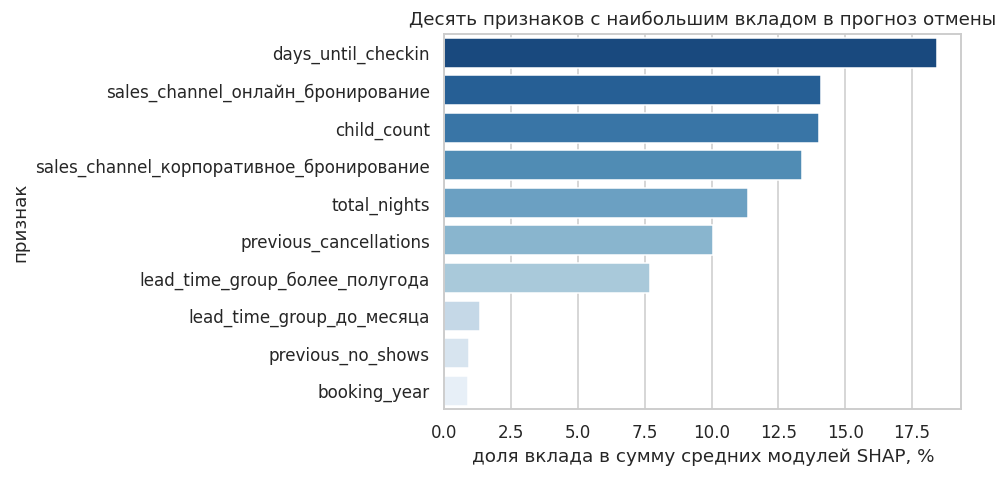

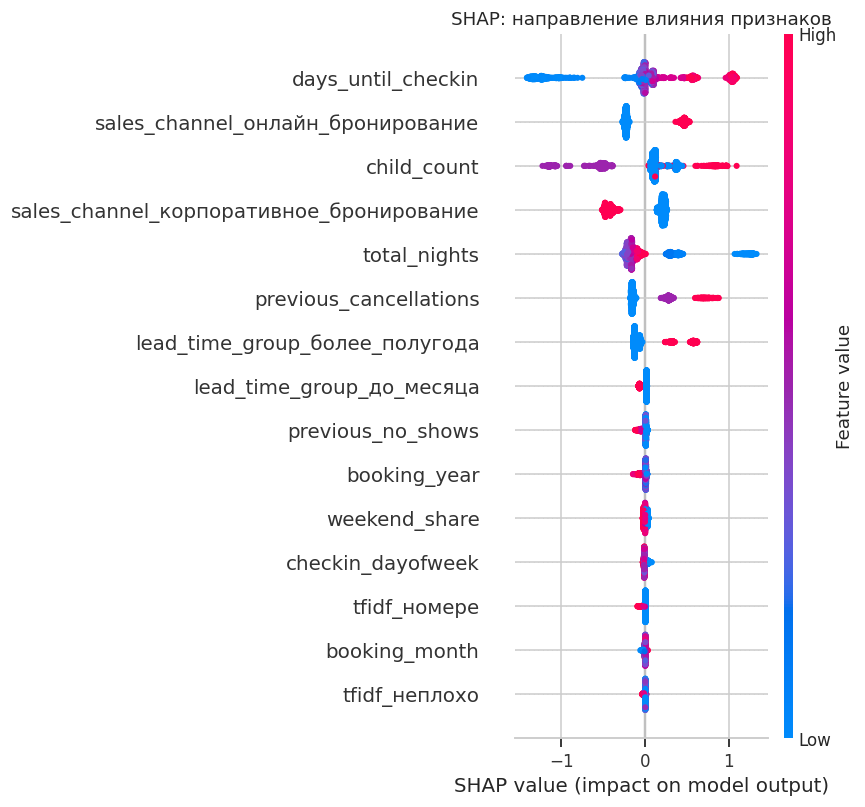

In [24]:
explainer = shap.TreeExplainer(base_model)
shap_sample_size = min(2000, A_cal.shape[0])
shap_sample = A_cal[:shap_sample_size]
shap_values = explainer.shap_values(shap_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[-1]

importance = (
    pd.DataFrame({"признак": feature_names, "средний_модуль_SHAP": np.abs(shap_values).mean(axis=0)})
    .sort_values("средний_модуль_SHAP", ascending=False)
    .reset_index(drop=True)
)
importance["доля_вклада_%"] = (
    importance["средний_модуль_SHAP"] / importance["средний_модуль_SHAP"].sum() * 100
).round(2)

# Направление влияния: знак корреляции значения признака с его вкладом в вероятность отмены.
directions = []
for position, name in enumerate(feature_names):
    column = shap_sample[:, position]
    if np.std(column) == 0:
        directions.append(np.nan)
    else:
        directions.append(np.corrcoef(column, shap_values[:, position])[0, 1])
importance["направление"] = np.where(
    pd.Series(directions).reindex(
        [feature_names.index(name) for name in importance["признак"]]
    ).values > 0,
    "рост признака повышает риск отмены",
    "рост признака снижает риск отмены",
)
top_features = importance.head(10)
display(top_features.set_index("признак"))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=top_features, y="признак", x="доля_вклада_%", ax=ax, palette="Blues_r")
ax.set_title("Десять признаков с наибольшим вкладом в прогноз отмены")
ax.set_xlabel("доля вклада в сумму средних модулей SHAP, %")
ax.set_ylabel("признак")
fig.tight_layout()
plt.show()

shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, max_display=15, show=False)
plt.title("SHAP: направление влияния признаков")
plt.tight_layout()
plt.show()

Чтобы перевести важность на язык заказчика, для ключевых признаков считаем фактическую долю отмен в крайних группах: это и есть ответ на вопрос «на сколько процентов признак меняет риск».

In [25]:
effects = []
cal_frame = X_cal.copy()
cal_frame["is_cancelled"] = y_cal
base_rate = cal_frame["is_cancelled"].mean()

for column, low_label, high_label in [
    ("days_until_checkin", "заезд ближе 45 дней", "заезд дальше 145 дней"),
    ("price_per_night", "дешёвые ночи", "дорогие ночи"),
    ("previous_cancellations", "без отмен в прошлом", "были отмены в прошлом"),
    ("customer_special_requests", "без пожеланий", "есть пожелания"),
    ("total_nights", "короткое проживание", "длинное проживание"),
]:
    values = cal_frame[column]
    low_mask = values <= values.quantile(0.25)
    high_mask = values >= values.quantile(0.75)
    if column in ("previous_cancellations", "customer_special_requests"):
        low_mask, high_mask = values == 0, values > 0
    effects.append([
        column, low_label, high_label,
        round(cal_frame.loc[low_mask, "is_cancelled"].mean() * 100, 2),
        round(cal_frame.loc[high_mask, "is_cancelled"].mean() * 100, 2),
        int(low_mask.sum()), int(high_mask.sum()),
    ])

for column in ["sales_channel", "season_group", "lead_time_group", "room_type"]:
    rates = cal_frame.groupby(column)["is_cancelled"].mean() * 100
    counts = cal_frame.groupby(column)["is_cancelled"].size()
    effects.append([
        column, f"{rates.idxmin()}", f"{rates.idxmax()}",
        round(rates.min(), 2), round(rates.max(), 2),
        int(counts[rates.idxmin()]), int(counts[rates.idxmax()]),
    ])

effects = pd.DataFrame(
    effects,
    columns=["признак", "группа_с_низким_риском", "группа_с_высоким_риском",
             "доля_отмен_низкая_%", "доля_отмен_высокая_%", "броней_низкая", "броней_высокая"],
).set_index("признак")
effects["разрыв_п_п"] = (effects["доля_отмен_высокая_%"] - effects["доля_отмен_низкая_%"]).round(2)
effects.columns.name = f"калибровочная выборка, средняя доля отмен {base_rate * 100:.2f}%"
display(effects)

"калибровочная выборка, средняя доля отмен 28.79%",группа_с_низким_риском,группа_с_высоким_риском,доля_отмен_низкая_%,доля_отмен_высокая_%,броней_низкая,броней_высокая,разрыв_п_п
признак,,,,,,,
days_until_checkin,заезд ближе 45 дней,заезд дальше 145 дней,14.6000,49.0600,1562,1549,34.4600
price_per_night,дешёвые ночи,дорогие ночи,28.4800,28.6900,4582,5894,0.2100
previous_cancellations,без отмен в прошлом,были отмены в прошлом,24.6100,39.2800,4393,1754,14.6700
customer_special_requests,без пожеланий,есть пожелания,29.1500,28.3700,3348,2799,-0.7800
total_nights,короткое проживание,длинное проживание,30.9600,26.6200,2723,1619,-4.3400
sales_channel,корпоративное_бронирование,онлайн_бронирование,15.3200,40.8100,2043,2012,25.4900
season_group,высокий_сезон,средний_сезон,27.5900,30.3100,2066,2042,2.7200
lead_time_group,до_месяца,более_полугода,14.6100,55.6900,1431,1063,41.0800
room_type,тип_5,тип_3,17.3900,50.0000,46,2,32.6100


**Выводы по важности признаков**

Десять признаков с наибольшим вкладом (доля от суммы средних модулей SHAP):

| Признак | Вклад | Как влияет |
|---|---|---|
| `days_until_checkin` | 18.43% | чем дальше заезд, тем выше риск отмены |
| `sales_channel_онлайн_бронирование` | 14.08% | онлайн-канал повышает риск |
| `child_count` | 14.04% | влияние немонотонное, см. ниже |
| `sales_channel_корпоративное_бронирование` | 13.39% | корпоративный канал снижает риск |
| `total_nights` | 11.38% | длинные поездки отменяют реже |
| `previous_cancellations` | 10.05% | каждая прошлая отмена повышает риск |
| `lead_time_group_более_полугода` | 7.71% | бронь за полгода и раньше - максимальный риск |
| `lead_time_group_до_месяца` | 1.34% | бронь в последний месяц - минимальный риск |
| `previous_no_shows` | 0.92% | подтверждённые заезды слегка снижают риск |
| `booking_year` | 0.87% | поздние годы наблюдений чуть спокойнее |

Числовые эффекты на калибровочной выборке (средняя доля отмен 28.79%):

- **Срок до заезда** - главный фактор: при заезде ближе 45 дней отменяется **14.60%** броней, дальше 145 дней - **49.06%**. Разрыв 34.5 процентных пункта. В категоризованном виде разрыв ещё шире: 14.61% для броней «до месяца» против 55.69% для «более полугода».
- **Канал продаж**: корпоративные брони отменяются в **15.32%** случаев, онлайн - в **40.81%**, разрыв 25.5 п.п.
- **История клиента**: без прошлых отмен - **24.61%**, с прошлыми отменами - **39.28%**, то есть прошлая отмена повышает риск на 14.7 п.п.
- **Число детей влияет немонотонно**, поэтому знак корреляции в таблице выше огрубляет картину: без детей отменяется 31.84% броней, с одним ребёнком - 15.85%, с двумя - 46.18%. Модель на дереве это различает, линейная - нет.
- **Стоимость ночи и число пожеланий не работают**: разрыв между дешёвыми и дорогими ночами 0.21 п.п., между бронями с пожеланиями и без - 0.78 п.п. Первое объясняется почти постоянным тарифом в данных.
- Разрыв по типу номера (17.39% против 50.00%) считать значимым нельзя: крайняя категория `тип_3` встречается в калибровочной выборке **два раза**.
- **Ни один признак из текстов отзывов не попал в топ-10.** Это прямое подтверждение вывода EDA: при честном объединении по дате отзыв относится к чужой поездке и предсказательной силы не несёт.

**Итог:** отмену определяют горизонт планирования, канал продаж и прошлое поведение клиента. Это управляемые факторы: на них можно влиять политикой предоплаты и работой с каналами, а не только реагировать прогнозом.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


Все показатели считаются на тестовой выборке: «до внедрения» - по фактическим значениям `y_test`, «после внедрения» - по предсказаниям модели `y_pred`.

**Формулы:**

$$IR_{до} = TotalSuccess \cdot AvgRev - TotalCancellations \cdot LostRev$$

$$IR_{после} = TP \cdot PerRebooking + TN \cdot AvgRev - FP \cdot CostFP - FN \cdot LostRev$$

$$\text{Динамика отмен} = \frac{\text{Доля отмен до} - \text{Доля отмен после}}{\text{Доля отмен до}} \cdot 100\%$$

$$\text{Динамика загрузки} = \frac{\text{Загрузка до} - \text{Загрузка после}}{\text{Загрузка до}} \cdot 100\%$$

**Принятые допущения:**

- доступные номера - все брони тестовой выборки: одной броне соответствует один номер, и до, и после внедрения знаменатель одинаковый;
- занятые номера до внедрения - состоявшиеся брони; после внедрения - вовремя перепроданные отмены (TP) и брони, которые модель оставила в силе и которые состоялись (TN). Номера из FP отель тоже сдаёт повторно, но исходный гость приезжает, поэтому в загрузку они не засчитываются: цена такого конфликта уже учтена в CostFP. Это консервативная оценка загрузки;
- отмены после внедрения - только незамеченные отмены (FN): по замеченным номер перепродан, и простоя нет.

"тестовая выборка, 6147 броней",случаев,цена_исхода_руб,вклад_в_IR_руб
исход,,,
"TP - отмены, распознанные вовремя",1053,45000,47385000
"TN - брони, которые состоялись",3680,64500,237360000
FP - ложные тревоги,697,-7000,-4879000
FN - пропущенные отмены,717,-64500,-46246500


динамика по формулам задания,до_внедрения,после_внедрения,изменение_%
показатель,,,
"Доля отмен бронирования, %",28.7900,11.6600,59.4900
"Загрузка отеля, %",71.2100,77.0000,-8.1300
"Доход IR, млн руб.",168.1500,233.6200,38.9300


,требование,факт,выполнено
целевой показатель,,,
Доля отмен после внедрения,не более 10%,11.6600,False
Снижение загрузки,не более 8%,-8.1300,True
Относительный IR,не менее 50%,38.9300,False


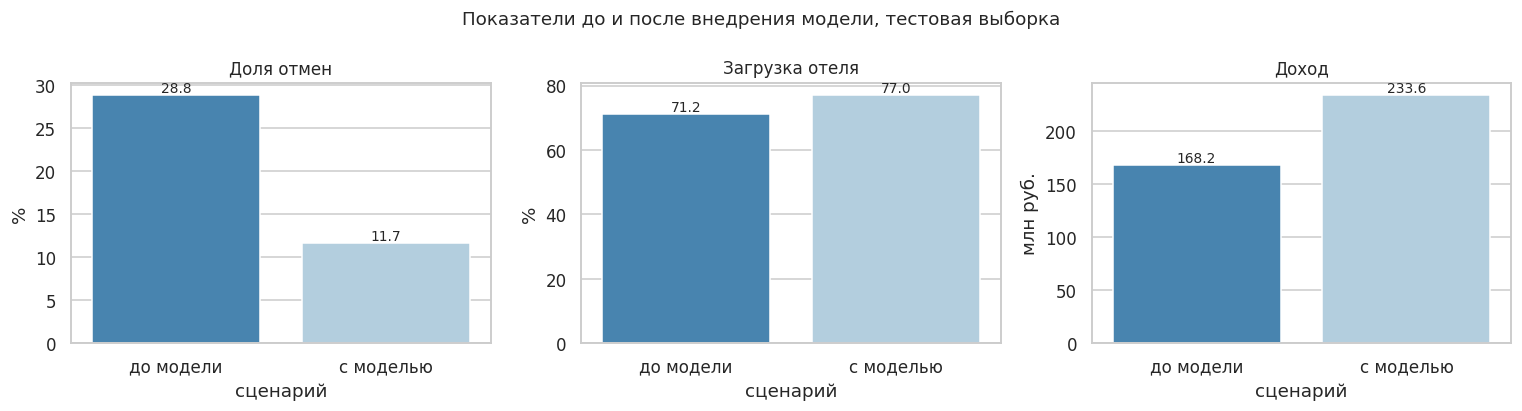

In [26]:
y_pred = (loaded_pipeline.predict_proba(X_test)[:, 1] >= loaded_threshold).astype(int)
economics = fp.business_metrics(y_test, y_pred)

confusion_summary = pd.DataFrame(
    [
        ["TP - отмены, распознанные вовремя", economics["TP"], fp.PER_REBOOKING, economics["TP"] * fp.PER_REBOOKING],
        ["TN - брони, которые состоялись", economics["TN"], fp.AVG_REV, economics["TN"] * fp.AVG_REV],
        ["FP - ложные тревоги", economics["FP"], -fp.COST_FP, -economics["FP"] * fp.COST_FP],
        ["FN - пропущенные отмены", economics["FN"], -fp.LOST_REV, -economics["FN"] * fp.LOST_REV],
    ],
    columns=["исход", "случаев", "цена_исхода_руб", "вклад_в_IR_руб"],
).set_index("исход")
confusion_summary.columns.name = f"тестовая выборка, {economics['n']} броней"
display(confusion_summary)

results = pd.DataFrame(
    [
        ["Доля отмен бронирования, %", economics["cancel_before_%"], economics["cancel_after_%"],
         economics["cancel_dynamics_%"]],
        ["Загрузка отеля, %", economics["occupancy_before_%"], economics["occupancy_after_%"],
         economics["occupancy_dynamics_%"]],
        ["Доход IR, млн руб.", economics["IR_before"] / 1e6, economics["IR_after"] / 1e6,
         economics["IR_rel_%"]],
    ],
    columns=["показатель", "до_внедрения", "после_внедрения", "изменение_%"],
).set_index("показатель")
results.columns.name = "динамика по формулам задания"
display(results.round(2))

goals = pd.DataFrame(
    [
        ["Доля отмен после внедрения", "не более 10%", economics["cancel_after_%"],
         economics["cancel_after_%"] <= 10.0],
        ["Снижение загрузки", "не более 8%", economics["occupancy_dynamics_%"],
         economics["occupancy_dynamics_%"] <= 8.0],
        ["Относительный IR", "не менее 50%", economics["IR_rel_%"], economics["IR_rel_%"] >= 50.0],
    ],
    columns=["целевой показатель", "требование", "факт", "выполнено"],
).set_index("целевой показатель")
display(goals.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (title, before, after, unit) in zip(axes, [
    ("Доля отмен", economics["cancel_before_%"], economics["cancel_after_%"], "%"),
    ("Загрузка отеля", economics["occupancy_before_%"], economics["occupancy_after_%"], "%"),
    ("Доход", economics["IR_before"] / 1e6, economics["IR_after"] / 1e6, "млн руб."),
]):
    sns.barplot(x=["до модели", "с моделью"], y=[before, after], ax=ax, palette="Blues_r")
    for position, value in enumerate([before, after]):
        ax.text(position, value, f"{value:,.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("сценарий")
    ax.set_ylabel(unit)
fig.suptitle("Показатели до и после внедрения модели, тестовая выборка", fontsize=12)
fig.tight_layout()
plt.show()

Порог - это управляемый параметр, и заказчику важно видеть размен между деньгами и долей отмен. Сравниваем три сценария на тестовой выборке: порог максимума IR, порог под цель по доле отмен и теоретический предел - безошибочная модель.

In [27]:
scenario_rows = []
for label, prediction in [
    (f"порог {best_threshold:.3f}: максимум IR", (proba_test >= best_threshold).astype(int)),
    (f"порог {threshold_cancel_goal:.3f}: цель по отменам",
     (proba_test >= threshold_cancel_goal).astype(int)),
    ("безошибочная модель (теоретический предел)", y_test.copy()),
]:
    metrics = fp.business_metrics(y_test, prediction)
    scenario_rows.append([
        label, metrics["TP"], metrics["FP"], metrics["FN"], metrics["IR_after"] / 1e6,
        metrics["IR_rel_%"], metrics["cancel_after_%"], metrics["occupancy_after_%"],
        metrics["occupancy_dynamics_%"],
    ])
scenarios = pd.DataFrame(
    scenario_rows,
    columns=["сценарий", "TP", "FP", "FN", "IR_после_млн", "IR_отн_%", "доля_отмен_%",
             "загрузка_%", "динамика_загрузки_%"],
).set_index("сценарий")
scenarios["цель по отменам"] = scenarios["доля_отмен_%"] <= 10.0
scenarios["цель по IR"] = scenarios["IR_отн_%"] >= 50.0
scenarios["цель по загрузке"] = scenarios["динамика_загрузки_%"] <= 8.0
display(scenarios.round(2))

# Какое качество ранжирования потребовалось бы для относительного IR в 50%:
# при доле отмен p неравенство сводится к линейной связи recall и доли ложных тревог.
n_test = len(y_test)
cancellations = int(y_test.sum())
successes = n_test - cancellations
ir_before = fp.revenue_before(y_test)
required_rows = []
for recall in [0.6, 0.7, 0.8, 0.9]:
    true_positive = cancellations * recall
    false_negative = cancellations - true_positive
    # доля ложных тревог, при которой относительный IR ровно 50%
    numerator = (1.5 * ir_before - true_positive * fp.PER_REBOOKING
                 - successes * fp.AVG_REV + false_negative * fp.LOST_REV)
    false_positive_rate = -numerator / (successes * (fp.AVG_REV + fp.COST_FP))
    required_rows.append([recall, round(false_positive_rate * 100, 2)])
requirements = pd.DataFrame(
    required_rows, columns=["recall_отмен", "допустимая_доля_ложных_тревог_%"]
).set_index("recall_отмен")
requirements.columns.name = "условие относительного IR = 50%"
display(requirements)

actual = pd.Series({
    "recall отмен на тесте": economics["TP"] / (economics["TP"] + economics["FN"]),
    "доля ложных тревог на тесте, %": economics["FP"] / (economics["FP"] + economics["TN"]) * 100,
    "ROC-AUC на тесте": roc_auc_score(y_test, proba_test),
}, name="фактическое качество модели")
display(actual.round(4).to_frame())

,TP,FP,FN,IR_после_млн,IR_отн_%,доля_отмен_%,загрузка_%,динамика_загрузки_%,цель по отменам,цель по IR,цель по загрузке
сценарий,,,,,,,,,,,
порог 0.380: максимум IR,1053,697,717,233.6200,38.9300,11.6600,77.0000,-8.1300,False,False,True
порог 0.330: цель по отменам,1219,1011,551,229.3500,36.3900,8.9600,74.5900,-4.7500,True,False,True
безошибочная модель (теоретический предел),1770,0,0,361.9700,115.2600,0.0000,100.0000,-40.4400,True,True,True


условие относительного IR = 50%,допустимая_доля_ложных_тревог_%
recall_отмен,
0.6000,10.2900
0.7000,16.4900
0.8000,22.6800
0.9000,28.8700


,фактическое качество модели
recall отмен на тесте,0.5949
"доля ложных тревог на тесте, %",15.9241
ROC-AUC на тесте,0.8104


Второй рычаг, помимо качества модели, - сами экономические параметры. `PerRebooking` = 45 000 руб. заметно ниже `AvgRev` = 64 500 руб.: перепроданный номер приносит на 30% меньше, чем обычная бронь. Считаем, при какой цене повторной сдачи текущая модель дала бы относительный IR в 50%.

In [28]:
def relative_ir(y_true, y_pred, per_rebooking=fp.PER_REBOOKING, cost_fp=fp.COST_FP):
    """Относительный IR при произвольных ценах перепродажи и ложной тревоги."""
    true_negative, false_positive, false_negative, true_positive = fp.confusion_counts(y_true, y_pred)
    after = (true_positive * per_rebooking + true_negative * fp.AVG_REV
             - false_positive * cost_fp - false_negative * fp.LOST_REV)
    before = fp.revenue_before(y_true)
    return (after - before) / abs(before) * 100


sensitivity = pd.DataFrame(
    [[price, round(relative_ir(y_test, y_pred, per_rebooking=price), 2)]
     for price in [45_000, 50_000, 55_000, 60_000, 64_500, 70_000, 80_000]],
    columns=["PerRebooking_руб", "IR_отн_%"],
).set_index("PerRebooking_руб")
sensitivity["цель 50% выполнена"] = sensitivity["IR_отн_%"] >= 50.0
sensitivity.columns.name = "чувствительность к цене повторной сдачи номера"
display(sensitivity)

# Цена перепродажи, при которой относительный IR ровно 50%, при текущей матрице ошибок.
required_price = (
    1.5 * economics["IR_before"] - economics["TN"] * fp.AVG_REV
    + economics["FP"] * fp.COST_FP + economics["FN"] * fp.LOST_REV
) / economics["TP"]
display(pd.Series({
    "требуемый PerRebooking, руб.": round(required_price, 0),
    "текущий PerRebooking, руб.": fp.PER_REBOOKING,
    "разрыв, руб.": round(required_price - fp.PER_REBOOKING, 0),
    "разрыв к AvgRev, %": round((required_price - fp.PER_REBOOKING) / fp.AVG_REV * 100, 2),
}, name="условие относительного IR = 50% при текущем качестве модели").to_frame())

чувствительность к цене повторной сдачи номера,IR_отн_%,цель 50% выполнена
PerRebooking_руб,,
45000,38.9300,False
50000,42.0700,False
55000,45.2000,False
60000,48.3300,False
64500,51.1500,True
70000,54.5900,True
80000,60.8500,True


,условие относительного IR = 50% при текущем качестве модели
"требуемый PerRebooking, руб.","62,671.0000"
"текущий PerRebooking, руб.","45,000.0000"
"разрыв, руб.","17,671.0000"
"разрыв к AvgRev, %",27.4000


### Выводы по экономической эффективности

**Показатели на тестовой выборке (6 147 броней, порог 0.380)**

| Показатель | До внедрения | После внедрения | Изменение по формуле задания |
|---|---|---|---|
| Доля отмен | 28.79% | 11.66% | **+59.49%** (снижение) |
| Загрузка отеля | 71.21% | 77.00% | **-8.13%** (рост) |
| Доход IR | 168.15 млн руб. | 233.62 млн руб. | **+38.93%** |

Знак в формулах задания устроен так, что положительная динамика отмен означает их снижение, а отрицательная динамика загрузки - её рост. В абсолютных величинах доля отмен упала на 17.13 п.п., загрузка выросла на 5.79 п.п., доход вырос на **65.47 млн руб. на 6 147 броней**, то есть на **10 650 руб. на одну бронь**.

**Из чего складывается прирост**

- 1 053 вовремя распознанные отмены дали 47.4 млн руб. от повторной сдачи номеров;
- 3 680 состоявшихся броней принесли 237.4 млн руб.;
- 697 ложных тревог стоили 4.9 млн руб. компенсаций;
- 717 пропущенных отмен обошлись в 46.2 млн руб. упущенного дохода.

**Достижение целевых показателей**

| Цель | Требование | Факт | Выполнено |
|---|---|---|---|
| Доля отмен | не более 10% | 11.66% | нет |
| Снижение загрузки | не более 8% | загрузка выросла | да |
| Относительный IR | не менее 50% | 38.93% | нет |

**Почему две цели из трёх не достигнуты и что это значит**

- Обе невыполненные цели упираются в одно - **качество ранжирования**. Модель ловит 59.5% отмен ценой 15.9% ложных тревог при ROC-AUC 0.810. Расчёт показывает: для относительного IR в 50% при recall 0.60 доля ложных тревог не должна превышать **10.29%**, а при recall 0.70 - 16.49%. Фактическая точка (recall 0.595 при 15.92% ложных тревог) лежит вне этой границы.
- Потолок метрики при идеальной модели - **+115.26%**, то есть цель в 50% достижима в принципе, но требует существенно более сильного сигнала в данных. Все три семейства моделей упёрлись в ROC-AUC около 0.81, а признаки из отзывов при честном объединении бесполезны, поэтому прирост качества нужно искать в новых данных, а не в тюнинге.
- **Цель по доле отмен достижима сменой порога.** При пороге 0.330 доля отмен падает до **8.96%**, загрузка растёт до 74.59%, а относительный IR составляет 36.39%. Цена выполнения цели - **4.27 млн руб. на тестовой выборке** (695 руб. на бронь).
- Второй рычаг - **цена повторной сдачи номера**. Сейчас `PerRebooking` = 45 000 руб. против `AvgRev` = 64 500 руб., то есть перепроданный номер приносит на 30% меньше обычной брони. При текущей матрице ошибок относительный IR достигает 50% при `PerRebooking` = **62 671 руб.**; уже при равенстве цен (64 500 руб.) он составил бы **51.15%**.

**Итог:** внедрение модели экономически выгодно - доход растёт на 38.9%, доля отмен снижается вдвое с лишним, загрузка увеличивается на 5.8 п.п. Формальная планка в 50% относительного IR не взята, и причина измерима: она требует либо более сильных признаков, либо менее убыточной перепродажи номеров.

## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Проделанная работа

**Подготовка данных**

- Обе таблицы выгружены из PostgreSQL через SQLAlchemy: `hotel_bookings` (35 341 строка) и `hotel_reviews` (25 177 строк).
- EDA выявил четыре проблемы. Пропусков в данных нет, но нашлись **4 608 полных дублей строк** (удалены, осталось 30 733 брони), **2 151 запись с `adult_count` = 100/200/300** (ошибка ввода лишних нулей, значения поделены на 100), **1 421 бронь с нулевой стоимостью** (незаполненное поле, переведено в пропуск и заполняется медианой train) и опечатка `не выбрант` в справочнике питания (сведена к `не выбран`).
- Главная находка EDA - **утечка через таблицу отзывов**: отзыв есть у всех 21 883 состоявшихся броней и ни у одной из 8 850 отменённых. Поэтому связывать таблицы по клиенту нельзя, и объединение выполнено только по дате через `merge_asof(direction="backward")` - каждой брони достаётся последний отзыв, известный отелю на момент её оформления. Число строк при объединении не изменилось, без отзыва остались 175 самых ранних броней (0.57%).
- Создано девять признаков по брони (`total_nights`, `weekend_share`, `guests_total`, `price_per_night`, `checkin_month`, `checkin_dayofweek`, `booking_month`, `booking_year`, `review_lag_days`) и две категоризации - сезонность заезда и группа срока до заезда. Исходные составляющие производных признаков убраны, чтобы не оставлять линейных зависимостей. Тексты отзывов векторизованы `TfidfVectorizer` (60 слов), словарь обучается только на train. Итоговая таблица - 30 733 строки и 23 столбца, после препроцессора 98 признаков.

**Моделирование**

- Выборки разделены со стратификацией: train 18 439 (60%), calibration 6 147 (20%), test 6 147 (20%). Кросс-валидация - `StratifiedShuffleSplit`, 3 фолда по 2 000 объектов в валидационной части.
- Протестированы три модели. Optuna оптимизировала **IR** по 20 испытаний на модель: для Random Forest - 4 гиперпараметра, для LightGBM - 6, для CatBoost - 4.
- **Победил CatBoost**: IR на кросс-валидации 22 758 000 руб. при ROC-AUC 0.8092 против 21 924 333 руб. (0.8051) у LightGBM и 21 560 833 руб. (0.7986) у Random Forest. Лучшие гиперпараметры - `iterations = 600`, `learning_rate = 0.0152`, `depth = 5`, `l2_leaf_reg = 4.2973`.
- Модель откалибрована изотонической регрессией на полной обучающей выборке (Brier 0.1505 против 0.1502), порог найден на калибровочной выборке по максимуму IR и равен **0.380** - почти совпадает с аналитическим порогом безубыточности 0.395.

**Оценка метрик**

- Калибровочная и тестовая выборки согласованы: IR 66.35 млн против 65.47 млн руб. (**расхождение 1.33%**), ROC-AUC 0.8106 против 0.8104. Переобучения нет.
- Матрица ошибок на тесте: TP = 1 053, FP = 697, FN = 717, TN = 3 680. Recall по отменам 0.59, precision 0.60, доля ложных тревог 15.9%.

**Анализ важности факторов**

- Использован **SHAP**: в отличие от встроенного `feature_importances_`, он показывает и силу, и направление влияния, а для деревьев считается точно. Топ вклада: срок до заезда (18.43%), онлайн-канал (14.08%), число детей (14.04%), корпоративный канал (13.39%), длительность проживания (11.38%), прошлые отмены (10.05%).
- Ни один TF-IDF признак в топ-10 не вошёл, что подтверждает вывод EDA о бесполезности отзывов при честном объединении.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

### Что это значит для бизнеса

**Достигнута ли цель проекта**

Цель - управляемо снижать потери от поздних отмен - **достигнута частично, но с положительным экономическим итогом**. Модель превращает неуправляемый овербукинг в расчёт: она заранее помечает рискованные брони, и на тестовой выборке из 6 147 броней это даёт **+65.47 млн руб. дохода, или 10 650 руб. на каждую бронь**. Из трёх формальных целевых показателей выполнен один, но ни по одному нет ухудшения относительно текущего положения дел.

**Результаты по ключевым метрикам**

| Показатель | До внедрения | После внедрения | Изменение | Цель | Выполнено |
|---|---|---|---|---|---|
| Доля отмен | 28.79% | 11.66% | (28.79 - 11.66) / 28.79 = **+59.49%** | 10% | нет |
| Загрузка отеля | 71.21% | 77.00% | (71.21 - 77.00) / 71.21 = **-8.13%**, то есть рост | падение не более 8% | да |
| Доход (IR) | 168.15 млн руб. | 233.62 млн руб. | (233.62 - 168.15) / 168.15 = **+38.93%** | не менее 50% | нет |

Что за этим стоит:

- **Доля поздних отмен падает с 28.8% до 11.7%** - более чем вдвое. Заявленный ориентир в 10% модель проходит при пороге 0.330: тогда доля отмен составляет 8.96%, а доход растёт на 36.39% вместо 38.93%. Цена выполнения цели - 695 руб. на бронь.
- **Загрузка растёт с 71.2% до 77.0%**, то есть на 5.8 процентных пункта, и вплотную подходит к плановым 80%. Требование «не потерять больше 8% загрузки» выполнено с запасом: загрузка не падает, а растёт.
- **Доход растёт на 38.9%** вместо целевых 50%. Причина измерима: чтобы выйти на 50%, при текущем recall в 60% доля ложных тревог должна опуститься с 15.9% до 10.3%. Это вопрос качества данных, а не настройки модели: три разных семейства алгоритмов упёрлись в ROC-AUC около 0.81.

**Десять признаков, определяющих риск отмены**

1. **Срок до заезда** (18.4% вклада) - главный фактор. Бронь дальше 145 дней отменяется в 49.1% случаев, ближе 45 дней - в 14.6%.
2. **Онлайн-канал** (14.1%) - повышает риск: 40.8% отмен против 28.8% в среднем.
3. **Число детей** (14.0%) - влияет неочевидно: с одним ребёнком отменяют реже всего (15.9%), с двумя - чаще всего (46.2%), без детей - 31.8%.
4. **Корпоративный канал** (13.4%) - самый надёжный сегмент: 15.3% отмен, вдвое ниже среднего.
5. **Длительность проживания** (11.4%) - длинные поездки отменяют реже: 26.6% против 31.0% у коротких.
6. **Прошлые отмены клиента** (10.1%) - каждая прошлая отмена повышает риск: 24.6% у клиентов без отмен против 39.3% у клиентов с отменами, а при трёх прошлых отменах доля доходит до 58.9%.
7. **Бронь более чем за полгода** (7.7%) - отдельная зона риска: 55.7% отмен.
8. **Бронь в течение месяца до заезда** (1.3%) - самая надёжная группа: 14.6% отмен.
9. **Подтверждённые заезды в прошлом** (0.9%) - слабо снижают риск.
10. **Год оформления брони** (0.9%) - в поздних годах наблюдений отмен немного меньше.

Отдельно стоит сказать, чего в списке **нет**: стоимость номера, тип питания, парковка и число пожеланий клиента практически не влияют на отмену (разрывы в пределах 1 процентного пункта). Оценки и тексты отзывов тоже не работают - в данных отзыв доступен только по состоявшимся поездкам, поэтому связать его с будущей отменой честно нельзя.

**Рекомендации**

1. **Внедрить модель с порогом 0.380 и пересматривать порог как управленческое решение.** Порог - это не техническая константа, а ручка управления: 0.380 максимизирует доход (+38.9%), 0.330 выполняет цель по доле отмен (8.96%) ценой 695 руб. на бронь. Рекомендуется начать с 0.380 и переключаться на 0.330 в периоды пиковой загрузки, когда репутационная цена простоя выше денежной.
2. **Изменить политику предоплаты для дальних броней и онлайн-канала.** Комбинация «онлайн-бронь более чем за полгода» - зона, где отменяется каждая вторая бронь. Невозвратный депозит или гибкий тариф с частичной предоплатой для этого сегмента снижает саму частоту отмен, а не только реагирует на неё. Это единственная мера, которая улучшает показатели без участия модели.
3. **Поднять цену повторной сдачи номера.** Сейчас перепроданный номер приносит 45 000 руб. против 64 500 руб. у обычной брони - минус 30%. Расчёт показывает: при 62 671 руб. текущая модель дала бы ровно 50% относительного IR, а при выравнивании цен - 51.15%. Работа с каналами срочного бронирования и партнёрскими программами закрывает разрыв до цели без единого изменения в модели.
4. **Начать собирать данные, которых не хватает.** Модель упирается в ROC-AUC 0.81, потому что в выгрузке нет ни идентификатора клиента в таблице броней, ни условий тарифа (предоплата, возвратность), ни истории общения с гостем. Добавление `customer_id` в `hotel_bookings` и признаков тарифа - самый прямой путь к цели в 50%: теоретический потолок при идеальном прогнозе составляет +115%, то есть запас для роста есть.